In [2]:
#1. import file, clean timestamp, convert to Sydney timezone, and show first 5 rows
from pathlib import Path
import pandas as pd

# --- File path ---
CsvPath = Path("ticks_XAUUSD_2026-04-17.csv")

# --- Load CSV ---
Df = pd.read_csv(CsvPath)

# --- Clean column names ---
Df.columns = [Col.strip() for Col in Df.columns]

# --- Clean timestamp text first ---
Df["timestamp"] = (
    Df["timestamp"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "T", regex=False)   # if any rows use space instead of T
)

# --- Parse timestamp robustly ---
# utc=True lets pandas normalize mixed offsets/forms safely, then we convert back to Sydney
Df["timestamp"] = pd.to_datetime(Df["timestamp"], errors="coerce", utc=True)

# --- Check for bad timestamp rows before continuing ---
BadTimestampRows = Df[Df["timestamp"].isna()]
print(f"Total Rows: {len(Df):,}")
print(f"Bad Timestamp Rows: {len(BadTimestampRows):,}")

# --- Convert to Australia/Sydney and unify display format ---
Df["timestamp"] = Df["timestamp"].dt.tz_convert("Australia/Sydney")

# Keep both:
# 1) real timezone-aware datetime for calculations
# 2) unified text version for easy visual checking/export if needed later
Df["timestampText"] = Df["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S.%f%z")

# --- Make numeric columns numeric where possible ---
for Col in ["bid", "ask", "mid", "spread", "kal", "k2"]:
    if Col in Df.columns:
        Df[Col] = pd.to_numeric(Df[Col], errors="coerce")

# --- Show first 5 rows for inspection ---
Df.head(5)

Total Rows: 198,175
Bad Timestamp Rows: 135


,id,symbol,timestamp,bid,ask,mid,spread,kal,k2,timestampText
0,43958393,XAUUSD,2026-04-17 08:01:00.952000+10:00,4794.55,4795.43,4794.99,0.88,NaN,NaN,2026-04-17 08:01:00.952000+1000
1,43958394,XAUUSD,2026-04-17 08:01:01.208000+10:00,4794.79,4796.00,4795.40,1.21,NaN,NaN,2026-04-17 08:01:01.208000+1000
2,43958395,XAUUSD,2026-04-17 08:01:01.425000+10:00,4794.60,4795.72,4795.16,1.12,NaN,NaN,2026-04-17 08:01:01.425000+1000
3,43958396,XAUUSD,2026-04-17 08:01:01.637000+10:00,4794.80,4795.97,4795.39,1.17,NaN,NaN,2026-04-17 08:01:01.637000+1000
4,43958397,XAUUSD,2026-04-17 08:01:01.857000+10:00,4794.80,4795.99,4795.40,1.19,NaN,NaN,2026-04-17 08:01:01.857000+1000


In [3]:
#2. remove bad timestamp rows, sort the ticks, calculate AO and AC oscillator columns, and preview the result

DfAc = (
    Df.dropna(subset=["timestamp", "mid"])
      .sort_values(["timestamp", "id"])
      .reset_index(drop=True)
      .copy()
)

# Traditional AC uses:
# AO = SMA(5) of median price - SMA(34) of median price
# AC = AO - SMA(5) of AO
#
# On tick data we do not have candle high/low bars yet,
# so for now we use tick "mid" as the price input.

DfAc["AoFast"] = DfAc["mid"].rolling(window=5, min_periods=5).mean()
DfAc["AoSlow"] = DfAc["mid"].rolling(window=34, min_periods=34).mean()
DfAc["Ao"] = DfAc["AoFast"] - DfAc["AoSlow"]
DfAc["AcSignal"] = DfAc["Ao"].rolling(window=5, min_periods=5).mean()
DfAc["Ac"] = DfAc["Ao"] - DfAc["AcSignal"]

print(f"Rows Before Cleaning: {len(Df):,}")
print(f"Rows After Cleaning:  {len(DfAc):,}")
print(f"Rows Removed:         {len(Df) - len(DfAc):,}")

DfAc[["id", "timestampText", "mid", "Ao", "Ac"]].head(10)

Rows Before Cleaning: 198,175
Rows After Cleaning:  198,040
Rows Removed:         135


,id,timestampText,mid,Ao,Ac
0,43958393,2026-04-17 08:01:00.952000+1000,4794.99,NaN,NaN
1,43958394,2026-04-17 08:01:01.208000+1000,4795.40,NaN,NaN
2,43958395,2026-04-17 08:01:01.425000+1000,4795.16,NaN,NaN
3,43958396,2026-04-17 08:01:01.637000+1000,4795.39,NaN,NaN
4,43958397,2026-04-17 08:01:01.857000+1000,4795.40,NaN,NaN
5,43958398,2026-04-17 08:01:02.107000+1000,4795.38,NaN,NaN
6,43958399,2026-04-17 08:01:02.326000+1000,4795.45,NaN,NaN
7,43958400,2026-04-17 08:01:02.539000+1000,4795.37,NaN,NaN
8,43958401,2026-04-17 08:01:02.754000+1000,4795.52,NaN,NaN
9,43958402,2026-04-17 08:01:02.955000+1000,4795.31,NaN,NaN


Valid AC Rows: 198,003
Random Window Start: 167,621
Random Window End:   168,021


,id,timestampText,mid,Ao,Ac
167621,44126167,2026-04-18 03:42:08.669000+1000,4857.37,0.429176,0.059224
167622,44126168,2026-04-18 03:42:08.907000+1000,4857.57,0.518941,0.106718
167623,44126169,2026-04-18 03:42:09.126000+1000,4857.57,0.559824,0.104200
167624,44126170,2026-04-18 03:42:09.584000+1000,4857.65,0.609412,0.107294
167625,44126171,2026-04-18 03:42:09.823000+1000,4857.73,0.650353,0.096812
167626,44126172,2026-04-18 03:42:10.568000+1000,4857.73,0.695588,0.088765
167627,44126173,2026-04-18 03:42:10.801000+1000,4857.69,0.693706,0.051929
167628,44126174,2026-04-18 03:42:11.054000+1000,4857.71,0.692882,0.024494
167629,44126175,2026-04-18 03:42:11.337000+1000,4857.86,0.702529,0.015518
167630,44126176,2026-04-18 03:42:11.601000+1000,4857.81,0.681471,-0.011765


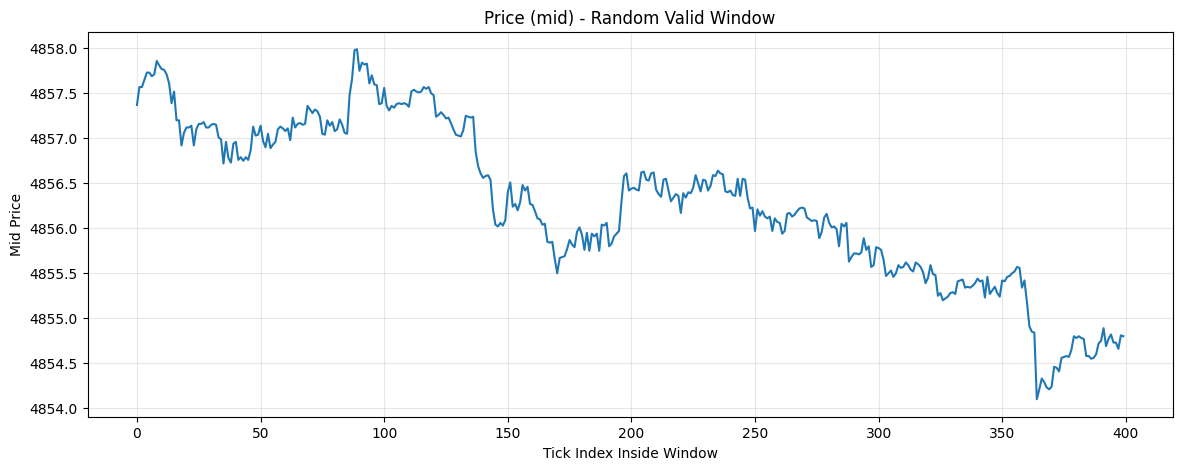

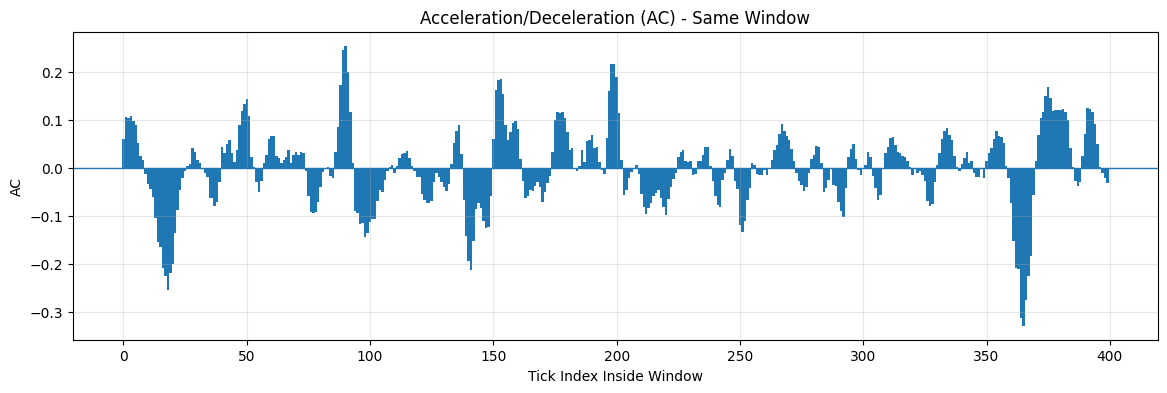

In [4]:
#3. select one valid random window, show an AC table sample, and draw price and AC charts for visual checking

import random
import matplotlib.pyplot as plt

# Keep only rows where AO and AC are already available
DfAcValid = DfAc.dropna(subset=["Ao", "Ac"]).reset_index(drop=True).copy()

print(f"Valid AC Rows: {len(DfAcValid):,}")

# Choose one random window for inspection
WindowSize = 400
RandomSeed = 42
random.seed(RandomSeed)

MaxStart = max(len(DfAcValid) - WindowSize, 0)
StartIndex = random.randint(0, MaxStart) if MaxStart > 0 else 0
EndIndex = StartIndex + WindowSize

SampleWindow = DfAcValid.iloc[StartIndex:EndIndex].copy()
SampleWindow["WindowIndex"] = range(len(SampleWindow))

print(f"Random Window Start: {StartIndex:,}")
print(f"Random Window End:   {EndIndex:,}")

# Small table to inspect the calculated values
display(
    SampleWindow[
        ["id", "timestampText", "mid", "Ao", "Ac"]
    ].head(15)
)

# --- Price chart ---
plt.figure(figsize=(14, 5))
plt.plot(SampleWindow["WindowIndex"], SampleWindow["mid"])
plt.title("Price (mid) - Random Valid Window")
plt.xlabel("Tick Index Inside Window")
plt.ylabel("Mid Price")
plt.grid(True, alpha=0.3)
plt.show()

# --- AC chart ---
plt.figure(figsize=(14, 4))
plt.bar(SampleWindow["WindowIndex"], SampleWindow["Ac"], width=1.0)
plt.axhline(0, linewidth=1)
plt.title("Acceleration/Deceleration (AC) - Same Window")
plt.xlabel("Tick Index Inside Window")
plt.ylabel("AC")
plt.grid(True, alpha=0.3)
plt.show()

Rows Available For Comparison: 197,997


,id,timestampText,mid,Ac,AcD,AcDema5
167621,44126173,2026-04-18 03:42:10.801000+1000,4857.69,0.051929,0.089576,0.088722
167622,44126174,2026-04-18 03:42:11.054000+1000,4857.71,0.024494,0.085588,0.087677
167623,44126175,2026-04-18 03:42:11.337000+1000,4857.86,0.015518,0.081082,0.085479
167624,44126176,2026-04-18 03:42:11.601000+1000,4857.81,-0.011765,0.051753,0.074237
167625,44126177,2026-04-18 03:42:11.829000+1000,4857.77,-0.032894,0.028435,0.058970
167626,44126178,2026-04-18 03:42:12.189000+1000,4857.76,-0.043847,0.004929,0.040956
167627,44126179,2026-04-18 03:42:12.637000+1000,4857.71,-0.060376,-0.019871,0.020681
167628,44126180,2026-04-18 03:42:12.867000+1000,4857.61,-0.103329,-0.036518,0.001615
167629,44126181,2026-04-18 03:42:13.091000+1000,4857.39,-0.154753,-0.050141,-0.015637
167630,44126182,2026-04-18 03:42:13.320000+1000,4857.52,-0.164871,-0.063859,-0.031711


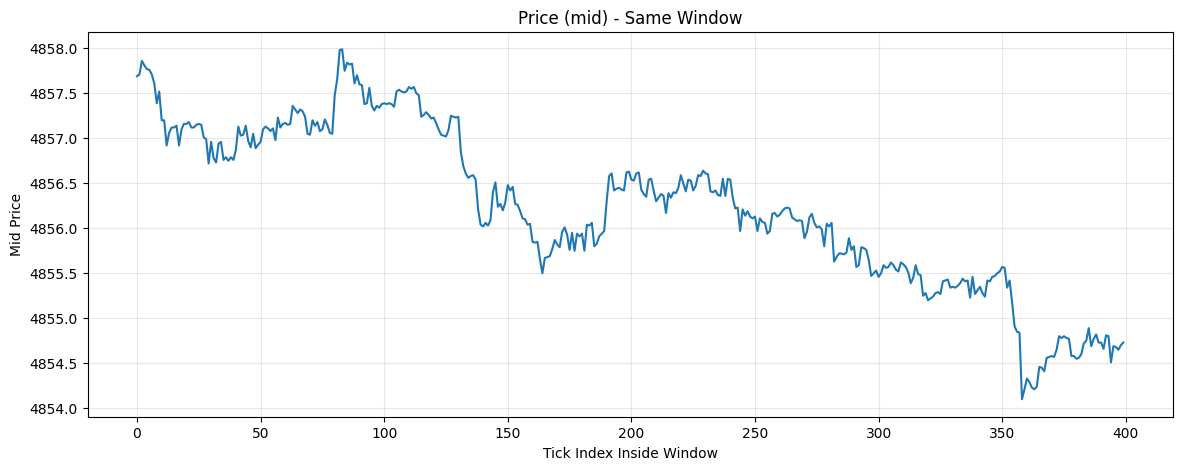

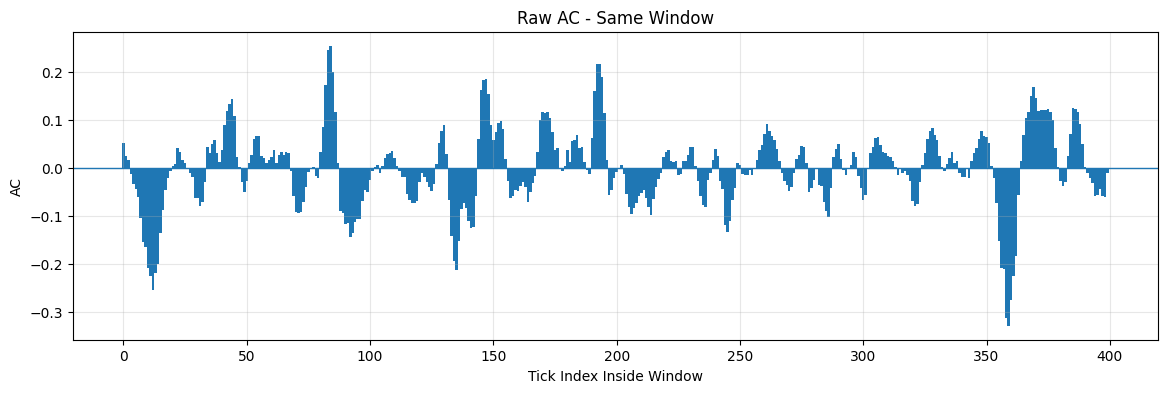

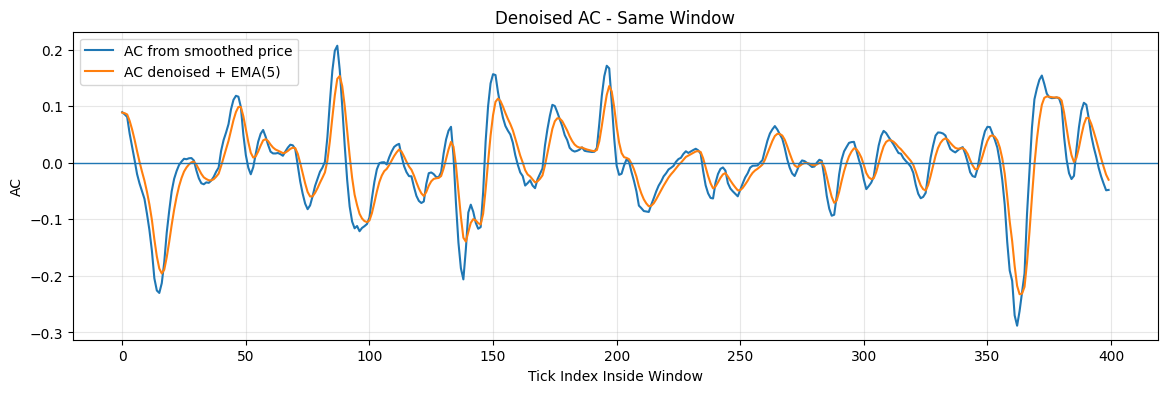

In [5]:
#4. build a denoised AC version from smoothed tick price, compare it with raw AC, and inspect the same window

import matplotlib.pyplot as plt

DfAcDenoised = DfAc.copy()

# Step 1: smooth the tick price itself first
# rolling median is good for removing tiny tick spikes without bending too much
DfAcDenoised["MidMedian7"] = DfAcDenoised["mid"].rolling(window=7, min_periods=7).median()

# Step 2: build AO from the smoothed price
DfAcDenoised["AoFastD"] = DfAcDenoised["MidMedian7"].rolling(window=5, min_periods=5).mean()
DfAcDenoised["AoSlowD"] = DfAcDenoised["MidMedian7"].rolling(window=34, min_periods=34).mean()
DfAcDenoised["AoD"] = DfAcDenoised["AoFastD"] - DfAcDenoised["AoSlowD"]

# Step 3: build AC from the denoised AO
DfAcDenoised["AcSignalD"] = DfAcDenoised["AoD"].rolling(window=5, min_periods=5).mean()
DfAcDenoised["AcD"] = DfAcDenoised["AoD"] - DfAcDenoised["AcSignalD"]

# Step 4: one more light smoothing directly on AC
DfAcDenoised["AcDema5"] = DfAcDenoised["AcD"].ewm(span=5, adjust=False).mean()

# Keep rows where all comparison values exist
DfCompare = DfAcDenoised.dropna(subset=["Ac", "AcD", "AcDema5"]).reset_index(drop=True).copy()

print(f"Rows Available For Comparison: {len(DfCompare):,}")

# Reuse the same random window idea
WindowSize = 400
StartIndexUse = StartIndex if "StartIndex" in globals() else 0
MaxStart = max(len(DfCompare) - WindowSize, 0)
StartIndexUse = min(StartIndexUse, MaxStart)
EndIndexUse = StartIndexUse + WindowSize

CompareWindow = DfCompare.iloc[StartIndexUse:EndIndexUse].copy()
CompareWindow["WindowIndex"] = range(len(CompareWindow))

display(
    CompareWindow[
        ["id", "timestampText", "mid", "Ac", "AcD", "AcDema5"]
    ].head(15)
)

# --- Price chart ---
plt.figure(figsize=(14, 5))
plt.plot(CompareWindow["WindowIndex"], CompareWindow["mid"])
plt.title("Price (mid) - Same Window")
plt.xlabel("Tick Index Inside Window")
plt.ylabel("Mid Price")
plt.grid(True, alpha=0.3)
plt.show()

# --- Raw AC chart ---
plt.figure(figsize=(14, 4))
plt.bar(CompareWindow["WindowIndex"], CompareWindow["Ac"], width=1.0)
plt.axhline(0, linewidth=1)
plt.title("Raw AC - Same Window")
plt.xlabel("Tick Index Inside Window")
plt.ylabel("AC")
plt.grid(True, alpha=0.3)
plt.show()

# --- Denoised AC comparison chart ---
plt.figure(figsize=(14, 4))
plt.plot(CompareWindow["WindowIndex"], CompareWindow["AcD"], label="AC from smoothed price")
plt.plot(CompareWindow["WindowIndex"], CompareWindow["AcDema5"], label="AC denoised + EMA(5)")
plt.axhline(0, linewidth=1)
plt.title("Denoised AC - Same Window")
plt.xlabel("Tick Index Inside Window")
plt.ylabel("AC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Rows Available: 198,003
Threshold Used: 0.30


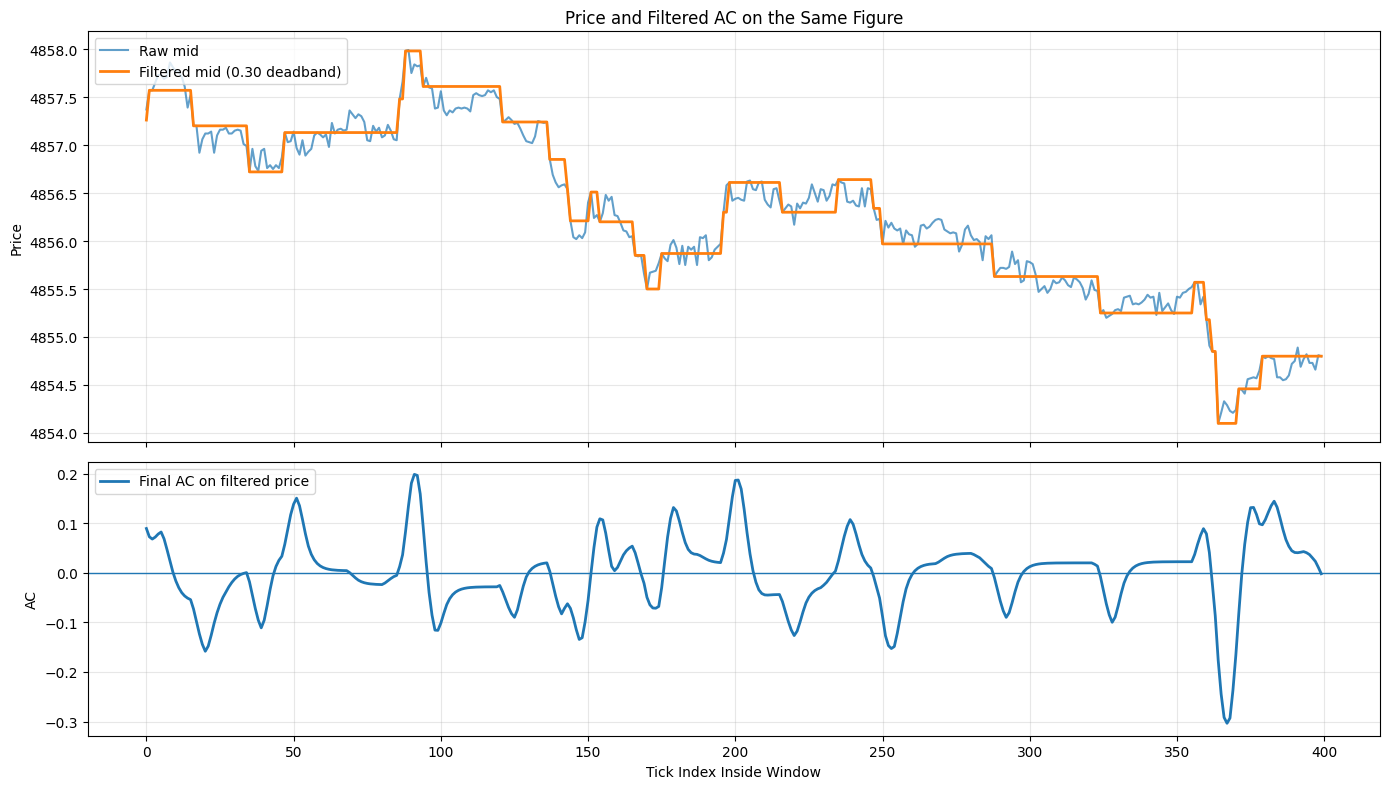

In [8]:
#5. apply a 30-cent deadband filter, rebuild AC on the filtered price, and show price and AC in one figure with shared x-axis

import numpy as np
import matplotlib.pyplot as plt

MoveThreshold = 0.30

DfFiltered = DfAc.copy().reset_index(drop=True)

MidValues = DfFiltered["mid"].to_numpy()
FilteredMidValues = np.empty(len(MidValues), dtype=float)

# Start from the first available mid
FilteredMidValues[0] = MidValues[0]
LastAcceptedPrice = MidValues[0]

for i in range(1, len(MidValues)):
    CurrentPrice = MidValues[i]

    # Ignore all movement smaller than threshold
    if abs(CurrentPrice - LastAcceptedPrice) < MoveThreshold:
        FilteredMidValues[i] = LastAcceptedPrice
    else:
        # Accept only meaningful move
        LastAcceptedPrice = CurrentPrice
        FilteredMidValues[i] = LastAcceptedPrice

DfFiltered["FilteredMid30"] = FilteredMidValues

# Rebuild AO / AC on filtered price
DfFiltered["AoFastF"] = DfFiltered["FilteredMid30"].rolling(window=5, min_periods=5).mean()
DfFiltered["AoSlowF"] = DfFiltered["FilteredMid30"].rolling(window=34, min_periods=34).mean()
DfFiltered["AoF"] = DfFiltered["AoFastF"] - DfFiltered["AoSlowF"]
DfFiltered["AcSignalF"] = DfFiltered["AoF"].rolling(window=5, min_periods=5).mean()
DfFiltered["AcF"] = DfFiltered["AoF"] - DfFiltered["AcSignalF"]

# Final smoothed AC on filtered price
DfFiltered["AcFEma5"] = DfFiltered["AcF"].ewm(span=5, adjust=False).mean()

DfFilteredValid = DfFiltered.dropna(subset=["FilteredMid30", "AcFEma5"]).reset_index(drop=True).copy()

print(f"Rows Available: {len(DfFilteredValid):,}")
print(f"Threshold Used: {MoveThreshold:.2f}")

WindowSize = 400
StartIndexUse = StartIndex if "StartIndex" in globals() else 0
MaxStart = max(len(DfFilteredValid) - WindowSize, 0)
StartIndexUse = min(StartIndexUse, MaxStart)
EndIndexUse = StartIndexUse + WindowSize

WindowFiltered = DfFilteredValid.iloc[StartIndexUse:EndIndexUse].copy()
WindowFiltered["WindowIndex"] = range(len(WindowFiltered))

# One figure, two stacked panels, shared x-axis
Figure, (AxisPrice, AxisAc) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# Top panel: raw mid + filtered mid
AxisPrice.plot(
    WindowFiltered["WindowIndex"],
    WindowFiltered["mid"],
    label="Raw mid",
    alpha=0.7
)

AxisPrice.plot(
    WindowFiltered["WindowIndex"],
    WindowFiltered["FilteredMid30"],
    label="Filtered mid (0.30 deadband)",
    linewidth=2
)

AxisPrice.set_title("Price and Filtered AC on the Same Figure")
AxisPrice.set_ylabel("Price")
AxisPrice.grid(True, alpha=0.3)
AxisPrice.legend(loc="upper left")

# Bottom panel: final filtered AC
AxisAc.plot(
    WindowFiltered["WindowIndex"],
    WindowFiltered["AcFEma5"],
    label="Final AC on filtered price",
    linewidth=2
)

AxisAc.axhline(0, linewidth=1)
AxisAc.set_xlabel("Tick Index Inside Window")
AxisAc.set_ylabel("AC")
AxisAc.grid(True, alpha=0.3)
AxisAc.legend(loc="upper left")

plt.tight_layout()
plt.show()

Rows Available: 198,026
Threshold Used: 0.30
RSI Period: 14


,id,timestampText,mid,FilteredMid30,DeltaF,RsiF
167621,44126144,2026-04-18 03:42:00.522000+1000,4856.46,4856.55,0.00,19.860882
167622,44126145,2026-04-18 03:42:01.047000+1000,4856.45,4856.55,0.00,19.860882
167623,44126146,2026-04-18 03:42:01.275000+1000,4856.53,4856.55,0.00,19.860882
167624,44126147,2026-04-18 03:42:01.505000+1000,4856.59,4856.55,0.00,19.860882
167625,44126148,2026-04-18 03:42:01.955000+1000,4856.66,4856.55,0.00,19.860882
167626,44126149,2026-04-18 03:42:02.479000+1000,4856.61,4856.55,0.00,19.860882
167627,44126150,2026-04-18 03:42:02.701000+1000,4856.60,4856.55,0.00,19.860882
167628,44126151,2026-04-18 03:42:02.938000+1000,4856.71,4856.55,0.00,19.860882
167629,44126152,2026-04-18 03:42:03.228000+1000,4856.78,4856.55,0.00,19.860882
167630,44126153,2026-04-18 03:42:03.760000+1000,4856.70,4856.55,0.00,19.860882


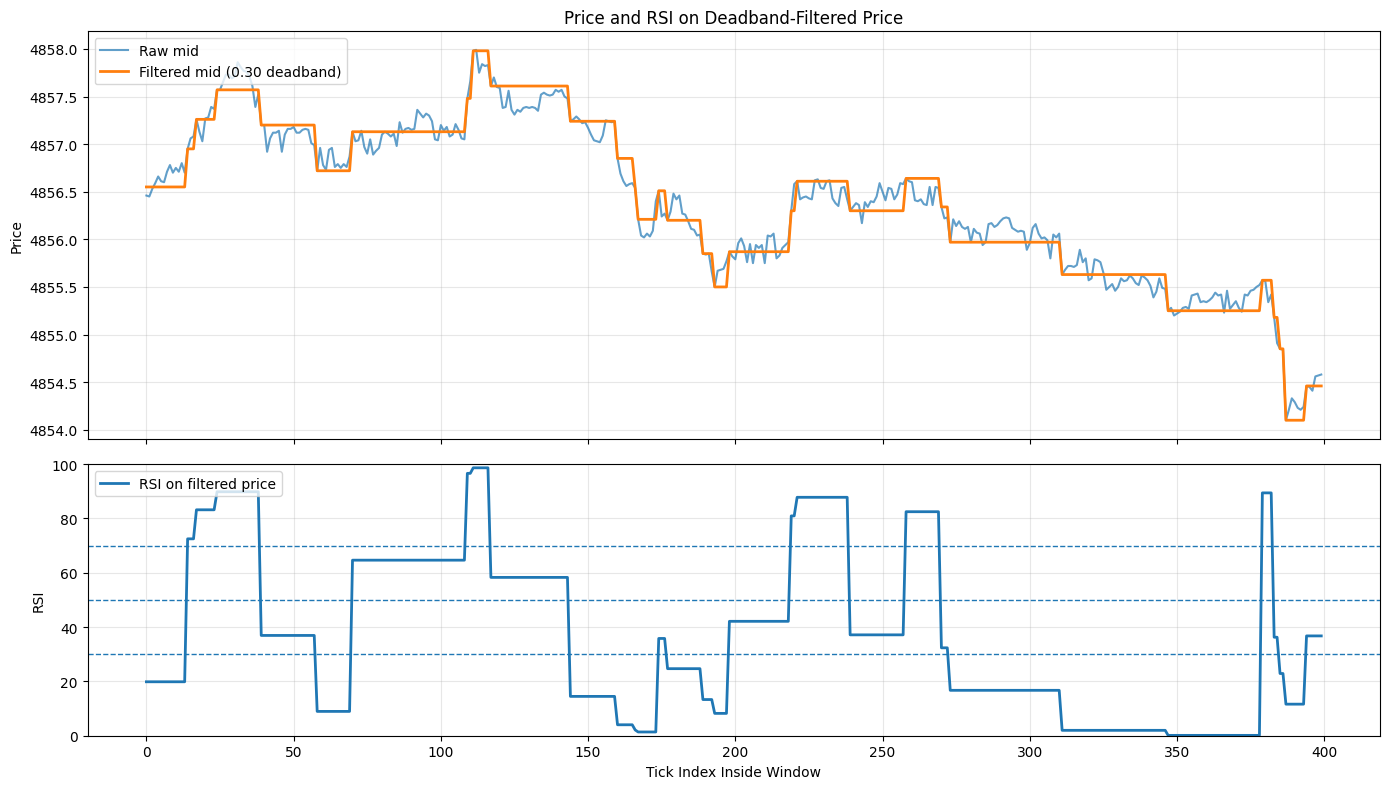

In [9]:
#6. apply the same 30-cent deadband filter, calculate RSI on the filtered price, and inspect whether it gives cleaner signals

import numpy as np
import matplotlib.pyplot as plt

MoveThreshold = 0.30
RsiPeriod = 14

DfRsi = DfAc.copy().reset_index(drop=True)

# --- Same deadband filter as before ---
MidValues = DfRsi["mid"].to_numpy()
FilteredMidValues = np.empty(len(MidValues), dtype=float)

FilteredMidValues[0] = MidValues[0]
LastAcceptedPrice = MidValues[0]

for i in range(1, len(MidValues)):
    CurrentPrice = MidValues[i]

    if abs(CurrentPrice - LastAcceptedPrice) < MoveThreshold:
        FilteredMidValues[i] = LastAcceptedPrice
    else:
        LastAcceptedPrice = CurrentPrice
        FilteredMidValues[i] = LastAcceptedPrice

DfRsi["FilteredMid30"] = FilteredMidValues

# --- Wilder RSI on filtered price ---
DfRsi["DeltaF"] = DfRsi["FilteredMid30"].diff()
DfRsi["GainF"] = DfRsi["DeltaF"].clip(lower=0)
DfRsi["LossF"] = -DfRsi["DeltaF"].clip(upper=0)

DfRsi["AvgGainF"] = DfRsi["GainF"].ewm(
    alpha=1 / RsiPeriod,
    adjust=False,
    min_periods=RsiPeriod
).mean()

DfRsi["AvgLossF"] = DfRsi["LossF"].ewm(
    alpha=1 / RsiPeriod,
    adjust=False,
    min_periods=RsiPeriod
).mean()

DfRsi["RsF"] = DfRsi["AvgGainF"] / DfRsi["AvgLossF"]
DfRsi["RsiF"] = 100 - (100 / (1 + DfRsi["RsF"]))

# Handle edge cases cleanly
DfRsi.loc[(DfRsi["AvgLossF"] == 0) & (DfRsi["AvgGainF"] > 0), "RsiF"] = 100
DfRsi.loc[(DfRsi["AvgGainF"] == 0) & (DfRsi["AvgLossF"] > 0), "RsiF"] = 0
DfRsi.loc[(DfRsi["AvgGainF"] == 0) & (DfRsi["AvgLossF"] == 0), "RsiF"] = 50

DfRsiValid = DfRsi.dropna(subset=["FilteredMid30", "RsiF"]).reset_index(drop=True).copy()

print(f"Rows Available: {len(DfRsiValid):,}")
print(f"Threshold Used: {MoveThreshold:.2f}")
print(f"RSI Period: {RsiPeriod}")

WindowSize = 400
StartIndexUse = StartIndex if "StartIndex" in globals() else 0
MaxStart = max(len(DfRsiValid) - WindowSize, 0)
StartIndexUse = min(StartIndexUse, MaxStart)
EndIndexUse = StartIndexUse + WindowSize

WindowRsi = DfRsiValid.iloc[StartIndexUse:EndIndexUse].copy()
WindowRsi["WindowIndex"] = range(len(WindowRsi))

display(
    WindowRsi[
        ["id", "timestampText", "mid", "FilteredMid30", "DeltaF", "RsiF"]
    ].head(20)
)

# --- One figure, two aligned panels ---
Figure, (AxisPrice, AxisRsi) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# Top: price
AxisPrice.plot(
    WindowRsi["WindowIndex"],
    WindowRsi["mid"],
    label="Raw mid",
    alpha=0.7
)

AxisPrice.plot(
    WindowRsi["WindowIndex"],
    WindowRsi["FilteredMid30"],
    label="Filtered mid (0.30 deadband)",
    linewidth=2
)

AxisPrice.set_title("Price and RSI on Deadband-Filtered Price")
AxisPrice.set_ylabel("Price")
AxisPrice.grid(True, alpha=0.3)
AxisPrice.legend(loc="upper left")

# Bottom: RSI
AxisRsi.plot(
    WindowRsi["WindowIndex"],
    WindowRsi["RsiF"],
    label="RSI on filtered price",
    linewidth=2
)

AxisRsi.axhline(70, linestyle="--", linewidth=1)
AxisRsi.axhline(50, linestyle="--", linewidth=1)
AxisRsi.axhline(30, linestyle="--", linewidth=1)

AxisRsi.set_xlabel("Tick Index Inside Window")
AxisRsi.set_ylabel("RSI")
AxisRsi.set_ylim(0, 100)
AxisRsi.grid(True, alpha=0.3)
AxisRsi.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [10]:
#7. scan the whole trading day for first-pass RSI divergences on the deadband-filtered price and count them

import pandas as pd

# We use the dataframe from the previous RSI step:
# DfRsi must already contain:
# - timestamp
# - timestampText
# - mid
# - FilteredMid30
# - RsiF

PivotSpan = 2          # pivot needs to be higher/lower than 2 swing points on each side
MinPriceDiff = 0.30    # require at least 30 cents difference between the two price pivots
MinRsiDiff = 3.0       # require at least 3 RSI points difference

DfDiv = DfRsi.copy().reset_index(drop=True)

# Keep only actual filtered-price change points so tiny repeated flats do not create fake pivots
DfDiv["FilteredMove"] = DfDiv["FilteredMid30"].diff().fillna(0.0)
DfSwing = DfDiv[DfDiv["FilteredMove"] != 0].copy().reset_index()
DfSwing.rename(columns={"index": "SourceIndex"}, inplace=True)

print(f"Total Rows In Day: {len(DfDiv):,}")
print(f"Swing Rows After Deadband Filter: {len(DfSwing):,}")

# --- Find swing pivot highs / lows on the filtered price ---
PivotRows = []

for i in range(PivotSpan, len(DfSwing) - PivotSpan):
    CenterPrice = DfSwing.loc[i, "FilteredMid30"]
    LeftPrices = DfSwing.loc[i - PivotSpan:i - 1, "FilteredMid30"]
    RightPrices = DfSwing.loc[i + 1:i + PivotSpan, "FilteredMid30"]

    IsPivotHigh = (CenterPrice > LeftPrices.max()) and (CenterPrice > RightPrices.max())
    IsPivotLow = (CenterPrice < LeftPrices.min()) and (CenterPrice < RightPrices.min())

    if IsPivotHigh or IsPivotLow:
        PivotRows.append({
            "SwingIndex": i,
            "SourceIndex": int(DfSwing.loc[i, "SourceIndex"]),
            "id": DfSwing.loc[i, "id"],
            "timestamp": DfSwing.loc[i, "timestamp"],
            "timestampText": DfSwing.loc[i, "timestampText"],
            "FilteredMid30": DfSwing.loc[i, "FilteredMid30"],
            "RsiF": DfSwing.loc[i, "RsiF"],
            "PivotType": "H" if IsPivotHigh else "L",
        })

DfPivots = pd.DataFrame(PivotRows)

print(f"Detected Price Pivots: {len(DfPivots):,}")

# --- Compare consecutive highs for bearish divergence and consecutive lows for bullish divergence ---
DivergenceRows = []

# Bearish divergence:
# price makes a higher high
# RSI makes a lower high
HighPivots = DfPivots[DfPivots["PivotType"] == "H"].reset_index(drop=True)

for i in range(1, len(HighPivots)):
    PrevRow = HighPivots.loc[i - 1]
    CurrRow = HighPivots.loc[i]

    PriceDiff = CurrRow["FilteredMid30"] - PrevRow["FilteredMid30"]
    RsiDiff = CurrRow["RsiF"] - PrevRow["RsiF"]

    if (PriceDiff >= MinPriceDiff) and (RsiDiff <= -MinRsiDiff):
        DivergenceRows.append({
            "SignalType": "BearishDivergence",
            "PrevId": int(PrevRow["id"]),
            "CurrId": int(CurrRow["id"]),
            "PrevTime": PrevRow["timestampText"],
            "CurrTime": CurrRow["timestampText"],
            "PrevPrice": float(PrevRow["FilteredMid30"]),
            "CurrPrice": float(CurrRow["FilteredMid30"]),
            "PrevRsi": float(PrevRow["RsiF"]),
            "CurrRsi": float(CurrRow["RsiF"]),
            "PriceDiff": float(PriceDiff),
            "RsiDiff": float(RsiDiff),
        })

# Bullish divergence:
# price makes a lower low
# RSI makes a higher low
LowPivots = DfPivots[DfPivots["PivotType"] == "L"].reset_index(drop=True)

for i in range(1, len(LowPivots)):
    PrevRow = LowPivots.loc[i - 1]
    CurrRow = LowPivots.loc[i]

    PriceDiff = CurrRow["FilteredMid30"] - PrevRow["FilteredMid30"]
    RsiDiff = CurrRow["RsiF"] - PrevRow["RsiF"]

    if (PriceDiff <= -MinPriceDiff) and (RsiDiff >= MinRsiDiff):
        DivergenceRows.append({
            "SignalType": "BullishDivergence",
            "PrevId": int(PrevRow["id"]),
            "CurrId": int(CurrRow["id"]),
            "PrevTime": PrevRow["timestampText"],
            "CurrTime": CurrRow["timestampText"],
            "PrevPrice": float(PrevRow["FilteredMid30"]),
            "CurrPrice": float(CurrRow["FilteredMid30"]),
            "PrevRsi": float(PrevRow["RsiF"]),
            "CurrRsi": float(CurrRow["RsiF"]),
            "PriceDiff": float(PriceDiff),
            "RsiDiff": float(RsiDiff),
        })

DfSignals = pd.DataFrame(DivergenceRows)

BearishCount = 0 if DfSignals.empty else int((DfSignals["SignalType"] == "BearishDivergence").sum())
BullishCount = 0 if DfSignals.empty else int((DfSignals["SignalType"] == "BullishDivergence").sum())
TotalCount = len(DfSignals)

print("")
print("Divergence Counts For Full Trading Day")
print(f"Bearish Divergence Count: {BearishCount}")
print(f"Bullish Divergence Count: {BullishCount}")
print(f"Total Divergence Count:   {TotalCount}")

if not DfSignals.empty:
    display(
        DfSignals.sort_values("CurrTime").reset_index(drop=True).head(20)
    )
else:
    print("No divergences found with the current settings.")

Total Rows In Day: 198,040
Swing Rows After Deadband Filter: 22,103
Detected Price Pivots: 6,071

Divergence Counts For Full Trading Day
Bearish Divergence Count: 214
Bullish Divergence Count: 224
Total Divergence Count:   438


,SignalType,PrevId,CurrId,PrevTime,CurrTime,PrevPrice,CurrPrice,PrevRsi,CurrRsi,PriceDiff,RsiDiff
0,BearishDivergence,43958952,43959013,2026-04-17 08:05:00.158000+1000,2026-04-17 08:05:29.208000+1000,4795.43,4796.99,92.309873,66.977780,1.56,-25.332093
1,BearishDivergence,43960589,43960755,2026-04-17 08:22:48.555000+1000,2026-04-17 08:25:27.657000+1000,4793.51,4795.37,88.246598,67.257804,1.86,-20.988794
2,BullishDivergence,43960779,43960853,2026-04-17 08:25:43.136000+1000,2026-04-17 08:27:00.609000+1000,4794.65,4793.96,14.906902,25.210254,-0.69,10.303352
3,BullishDivergence,43961101,43961134,2026-04-17 08:30:23.093000+1000,2026-04-17 08:30:39.545000+1000,4792.29,4791.89,5.465048,9.493457,-0.40,4.028409
4,BearishDivergence,43961255,43961334,2026-04-17 08:32:34.003000+1000,2026-04-17 08:33:22.583000+1000,4792.98,4793.51,97.428352,84.651492,0.53,-12.776860
5,BearishDivergence,43961474,43961549,2026-04-17 08:34:17.373000+1000,2026-04-17 08:34:46.546000+1000,4794.74,4795.18,96.071058,87.502738,0.44,-8.568320
6,BearishDivergence,43963259,43963402,2026-04-17 08:55:42.566000+1000,2026-04-17 08:57:24.135000+1000,4796.55,4796.90,77.963961,68.713544,0.35,-9.250417
7,BearishDivergence,43963895,43964006,2026-04-17 09:04:10.030000+1000,2026-04-17 09:05:11.504000+1000,4793.78,4795.07,92.458961,88.800765,1.29,-3.658196
8,BearishDivergence,43964078,43964172,2026-04-17 09:05:59.784000+1000,2026-04-17 09:07:29.348000+1000,4795.19,4795.77,95.365688,75.348130,0.58,-20.017557
9,BullishDivergence,43965667,43965751,2026-04-17 09:27:12.460000+1000,2026-04-17 09:28:12.446000+1000,4795.91,4795.36,4.166750,24.420356,-0.55,20.253607


In [11]:
#8. build review links for every divergence so each one can be opened directly in datavis

from IPython.display import HTML, display
import pandas as pd

# Adjust these if you want a wider or tighter view
BeforeTicks = 300
AfterTicks = 900

BaseUrl = (
    "https://www.datavis.au/live"
    "?mode=review"
    "&run=stop"
    "&showTicks=1"
    "&showEvents=0"
    "&showStructure=0"
    "&showRanges=0"
    "&window={WindowCount}"
    "&speed=1"
    "&id={StartId}"
)

if "DfSignals" not in globals():
    raise ValueError("DfSignals does not exist. Run the divergence scan cell first.")

if DfSignals.empty:
    print("No divergence signals were found, so no review links were created.")
else:
    # Use the cleaned day dataframe to map each tick id to its row position
    DfMap = DfRsi[["id", "timestampText", "mid", "FilteredMid30", "RsiF"]].reset_index(drop=True).copy()
    IdToPos = pd.Series(DfMap.index.to_numpy(), index=DfMap["id"]).to_dict()

    ReviewRows = []

    for _, Row in DfSignals.sort_values("CurrTime").reset_index(drop=True).iterrows():
        PrevId = int(Row["PrevId"])
        CurrId = int(Row["CurrId"])

        if PrevId not in IdToPos or CurrId not in IdToPos:
            continue

        PrevPos = int(IdToPos[PrevId])
        CurrPos = int(IdToPos[CurrId])

        FirstPos = min(PrevPos, CurrPos)
        LastPos = max(PrevPos, CurrPos)

        StartPos = max(0, FirstPos - BeforeTicks)
        EndPos = min(len(DfMap) - 1, LastPos + AfterTicks)

        StartId = int(DfMap.loc[StartPos, "id"])
        EndId = int(DfMap.loc[EndPos, "id"])
        WindowCount = int(EndPos - StartPos + 1)

        ReviewUrl = BaseUrl.format(
            WindowCount=WindowCount,
            StartId=StartId,
        )

        ReviewRows.append({
            "SignalType": Row["SignalType"],
            "PrevId": PrevId,
            "CurrId": CurrId,
            "PrevTime": Row["PrevTime"],
            "CurrTime": Row["CurrTime"],
            "PrevPrice": Row["PrevPrice"],
            "CurrPrice": Row["CurrPrice"],
            "PrevRsi": Row["PrevRsi"],
            "CurrRsi": Row["CurrRsi"],
            "PriceDiff": Row["PriceDiff"],
            "RsiDiff": Row["RsiDiff"],
            "StartId": StartId,
            "EndId": EndId,
            "WindowCount": WindowCount,
            "ReviewUrl": ReviewUrl,
        })

    DfReviewLinks = pd.DataFrame(ReviewRows)

    print(f"Review Links Created: {len(DfReviewLinks):,}")
    print(f"BeforeTicks: {BeforeTicks}")
    print(f"AfterTicks:  {AfterTicks}")

    # Save for later use
    OutputPath = "rsi_divergence_review_links.csv"
    DfReviewLinks.to_csv(OutputPath, index=False)
    print(f"Saved: {OutputPath}")

    # Clickable table for quick opening
    DfReviewShow = DfReviewLinks.copy()
    DfReviewShow["Open"] = DfReviewShow["ReviewUrl"].apply(
        lambda Url: f'<a href="{Url}" target="_blank">Open review</a>'
    )

    display(
        HTML(
            DfReviewShow[
                [
                    "SignalType",
                    "PrevTime",
                    "CurrTime",
                    "PrevId",
                    "CurrId",
                    "StartId",
                    "WindowCount",
                    "Open",
                ]
            ].to_html(escape=False, index=False)
        )
    )

    # Also show plain links in case you want to copy them directly
    pd.set_option("display.max_colwidth", 200)
    display(
        DfReviewLinks[
            [
                "SignalType",
                "PrevTime",
                "CurrTime",
                "ReviewUrl",
            ]
        ].head(20)
    )

Review Links Created: 438
BeforeTicks: 300
AfterTicks:  900
Saved: rsi_divergence_review_links.csv


SignalType,PrevTime,CurrTime,PrevId,CurrId,StartId,WindowCount,Open
BearishDivergence,2026-04-17 08:05:00.158000+1000,2026-04-17 08:05:29.208000+1000,43958952,43959013,43958652,1262,Open review
BearishDivergence,2026-04-17 08:22:48.555000+1000,2026-04-17 08:25:27.657000+1000,43960589,43960755,43960289,1367,Open review
BullishDivergence,2026-04-17 08:25:43.136000+1000,2026-04-17 08:27:00.609000+1000,43960779,43960853,43960479,1275,Open review
BullishDivergence,2026-04-17 08:30:23.093000+1000,2026-04-17 08:30:39.545000+1000,43961101,43961134,43960801,1234,Open review
BearishDivergence,2026-04-17 08:32:34.003000+1000,2026-04-17 08:33:22.583000+1000,43961255,43961334,43960954,1280,Open review
BearishDivergence,2026-04-17 08:34:17.373000+1000,2026-04-17 08:34:46.546000+1000,43961474,43961549,43961174,1276,Open review
BearishDivergence,2026-04-17 08:55:42.566000+1000,2026-04-17 08:57:24.135000+1000,43963259,43963402,43962959,1344,Open review
BearishDivergence,2026-04-17 09:04:10.030000+1000,2026-04-17 09:05:11.504000+1000,43963895,43964006,43963595,1312,Open review
BearishDivergence,2026-04-17 09:05:59.784000+1000,2026-04-17 09:07:29.348000+1000,43964078,43964172,43963778,1294,Open review
BullishDivergence,2026-04-17 09:27:12.460000+1000,2026-04-17 09:28:12.446000+1000,43965667,43965751,43965367,1285,Open review


,SignalType,PrevTime,CurrTime,ReviewUrl
0,BearishDivergence,2026-04-17 08:05:00.158000+1000,2026-04-17 08:05:29.208000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1262&speed=1&id=43958652
1,BearishDivergence,2026-04-17 08:22:48.555000+1000,2026-04-17 08:25:27.657000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1367&speed=1&id=43960289
2,BullishDivergence,2026-04-17 08:25:43.136000+1000,2026-04-17 08:27:00.609000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1275&speed=1&id=43960479
3,BullishDivergence,2026-04-17 08:30:23.093000+1000,2026-04-17 08:30:39.545000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1234&speed=1&id=43960801
4,BearishDivergence,2026-04-17 08:32:34.003000+1000,2026-04-17 08:33:22.583000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1280&speed=1&id=43960954
5,BearishDivergence,2026-04-17 08:34:17.373000+1000,2026-04-17 08:34:46.546000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1276&speed=1&id=43961174
6,BearishDivergence,2026-04-17 08:55:42.566000+1000,2026-04-17 08:57:24.135000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1344&speed=1&id=43962959
7,BearishDivergence,2026-04-17 09:04:10.030000+1000,2026-04-17 09:05:11.504000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1312&speed=1&id=43963595
8,BearishDivergence,2026-04-17 09:05:59.784000+1000,2026-04-17 09:07:29.348000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1294&speed=1&id=43963778
9,BullishDivergence,2026-04-17 09:27:12.460000+1000,2026-04-17 09:28:12.446000+1000,https://www.datavis.au/live?mode=review&run=stop&showTicks=1&showEvents=0&showStructure=0&showRanges=0&window=1285&speed=1&id=43965367


Drawing 10 signal pictures...
Saving into folder: divergence_pictures


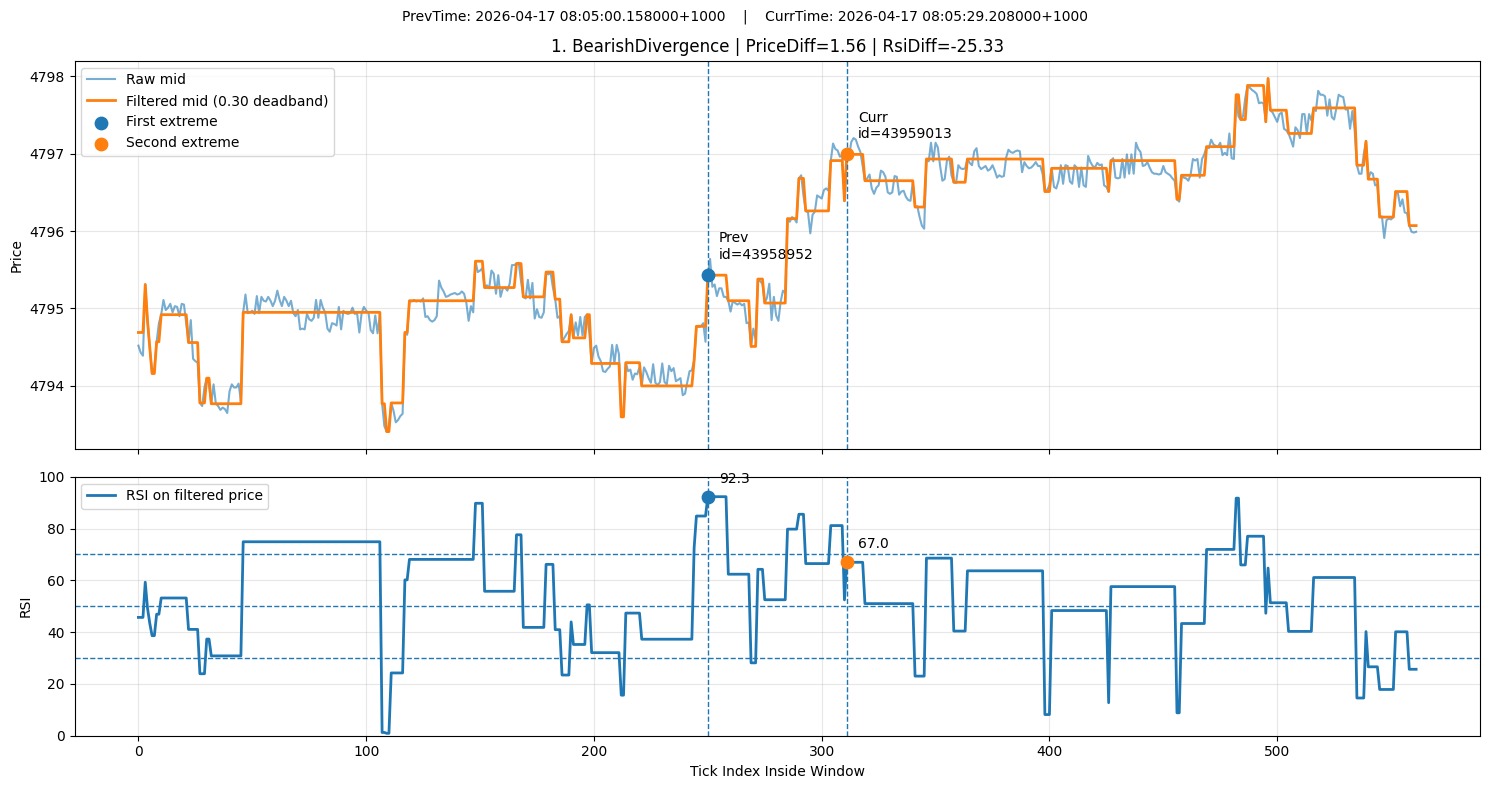

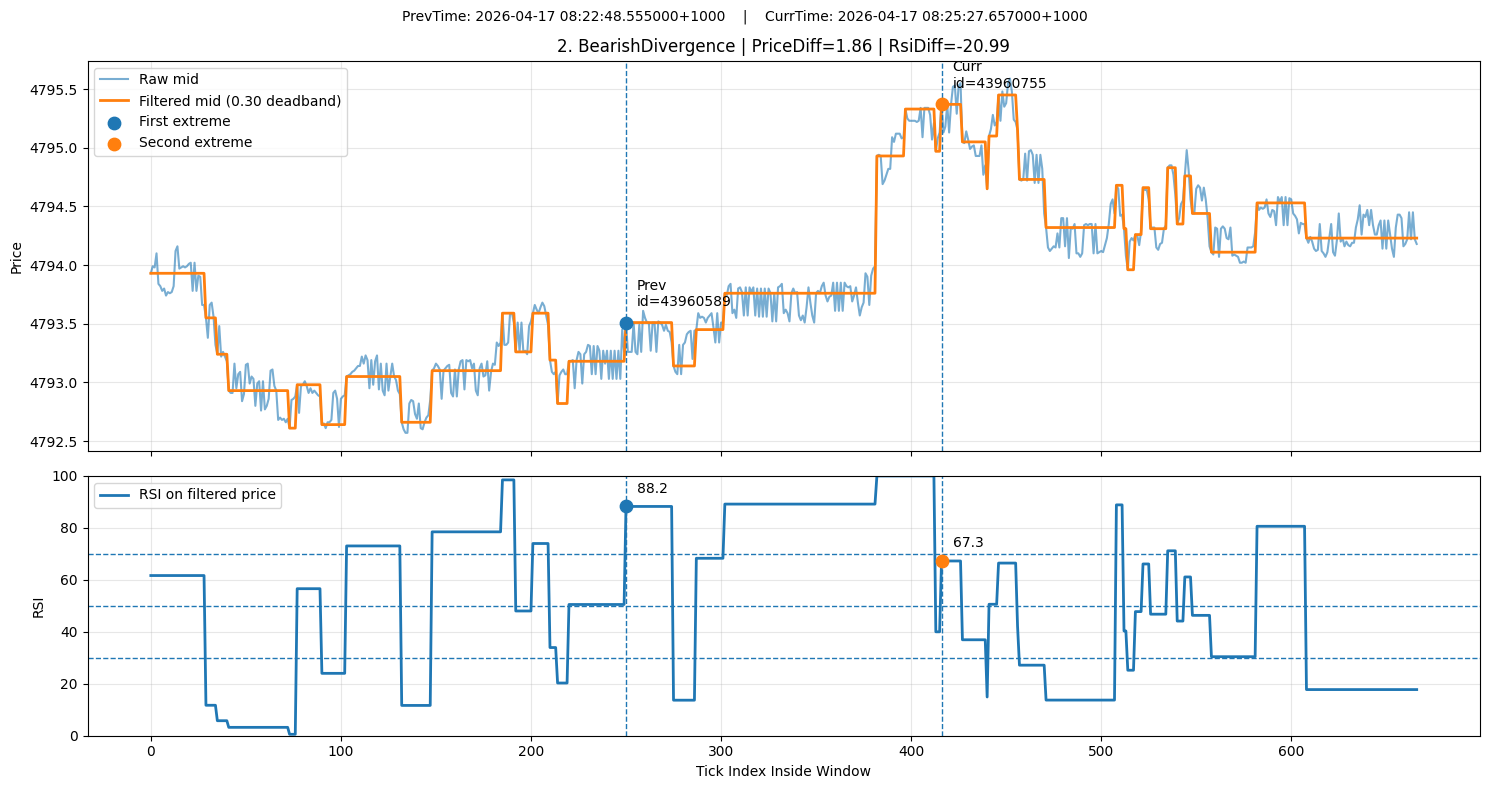

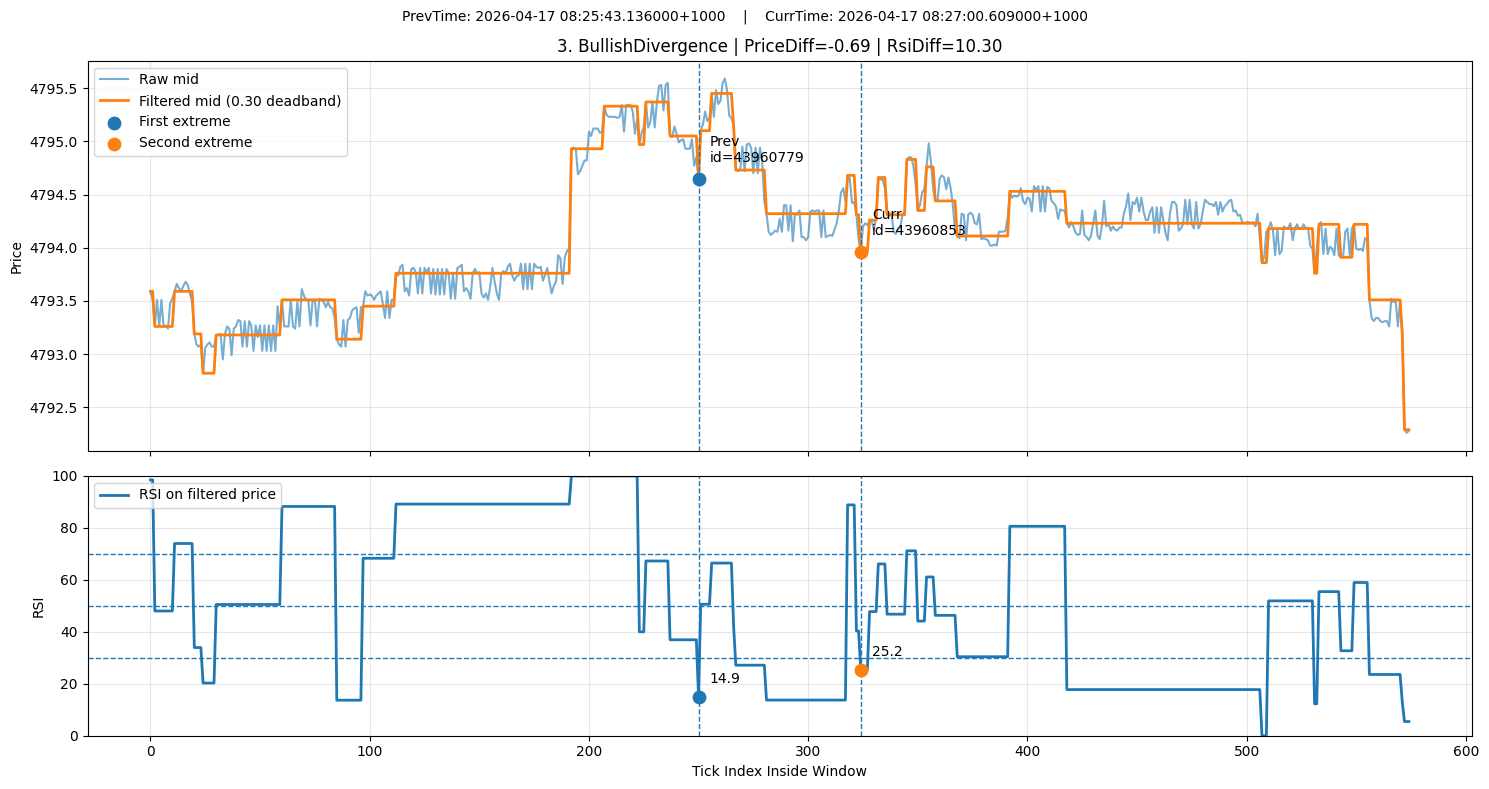

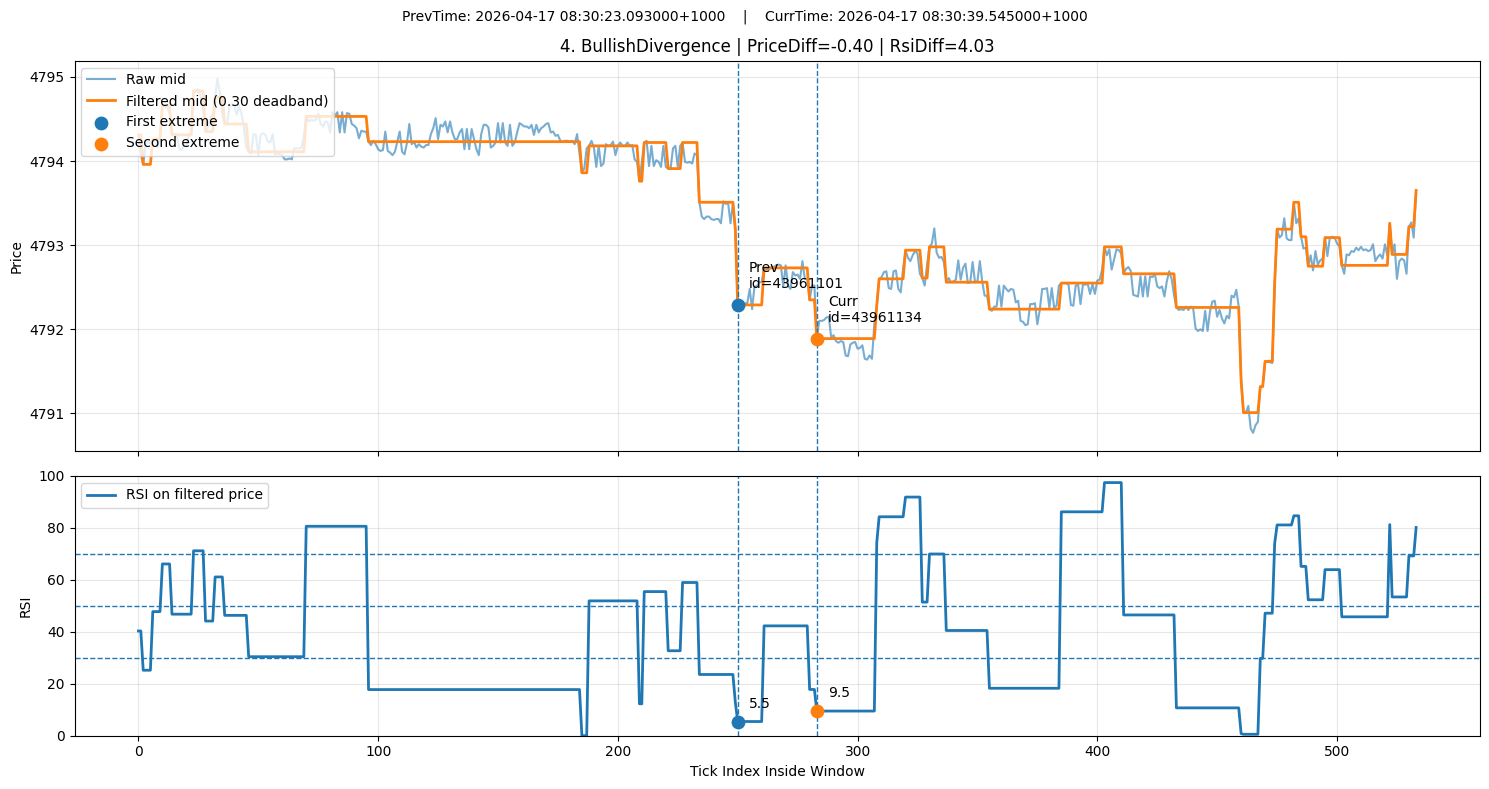

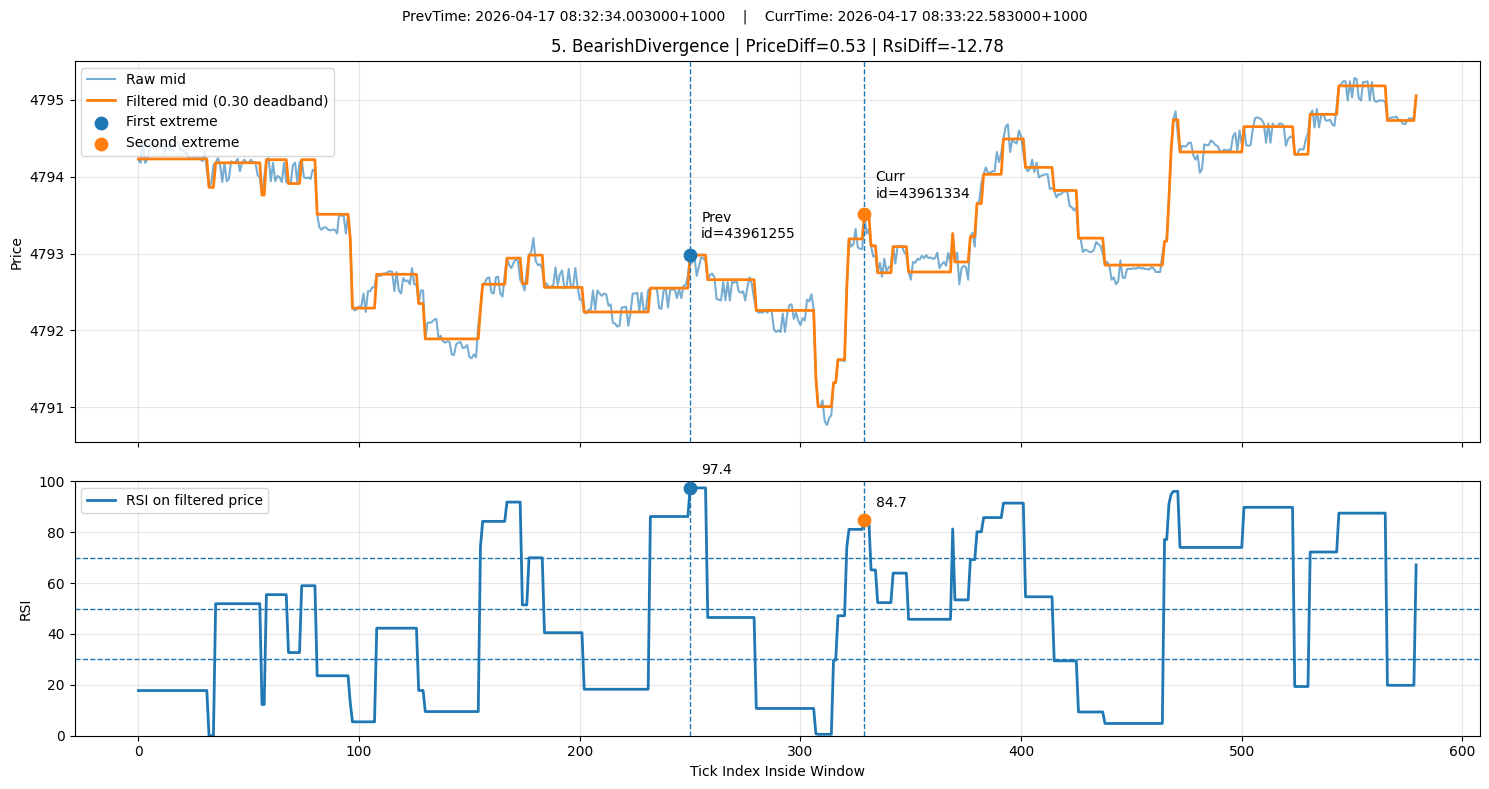

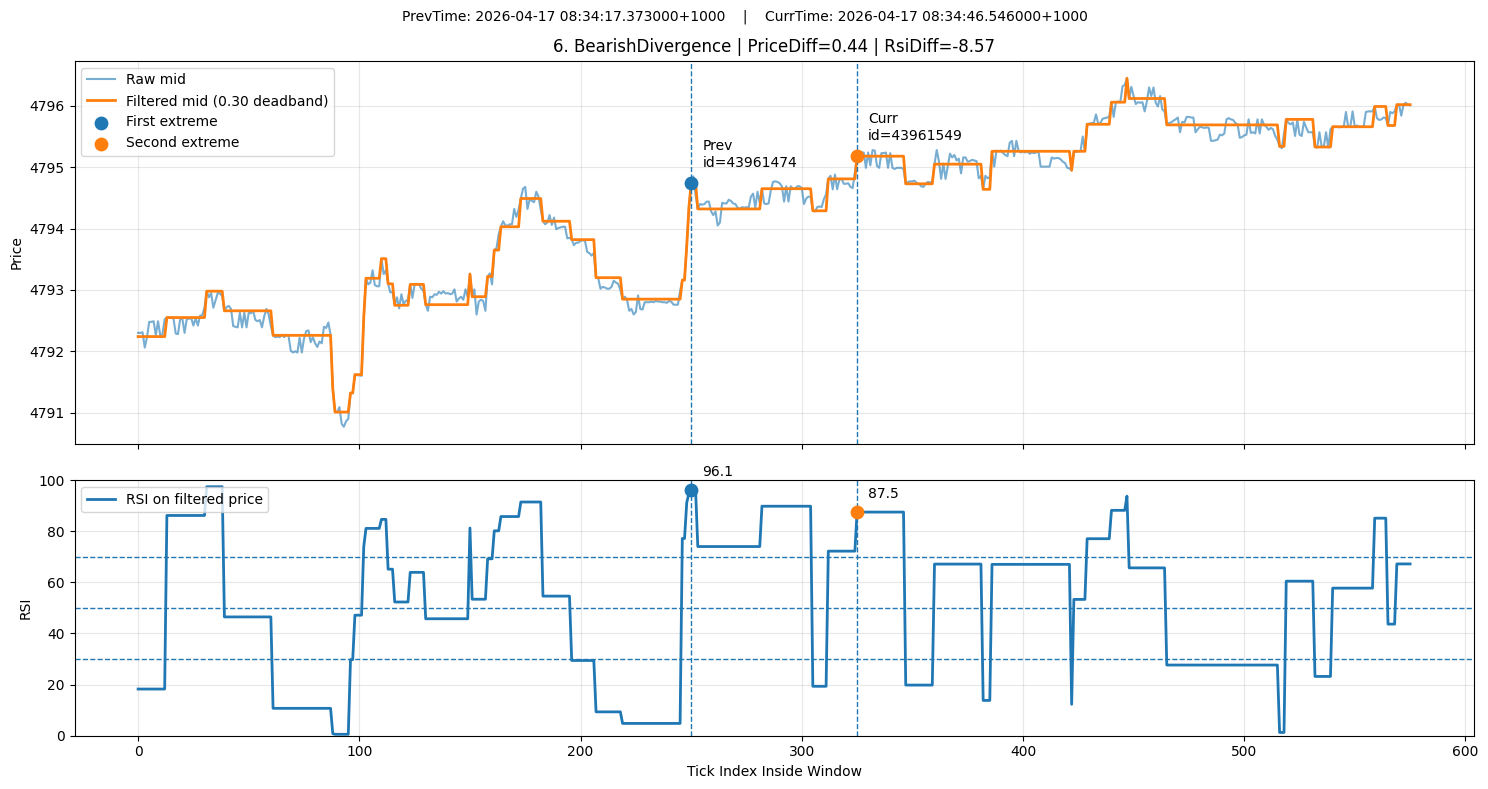

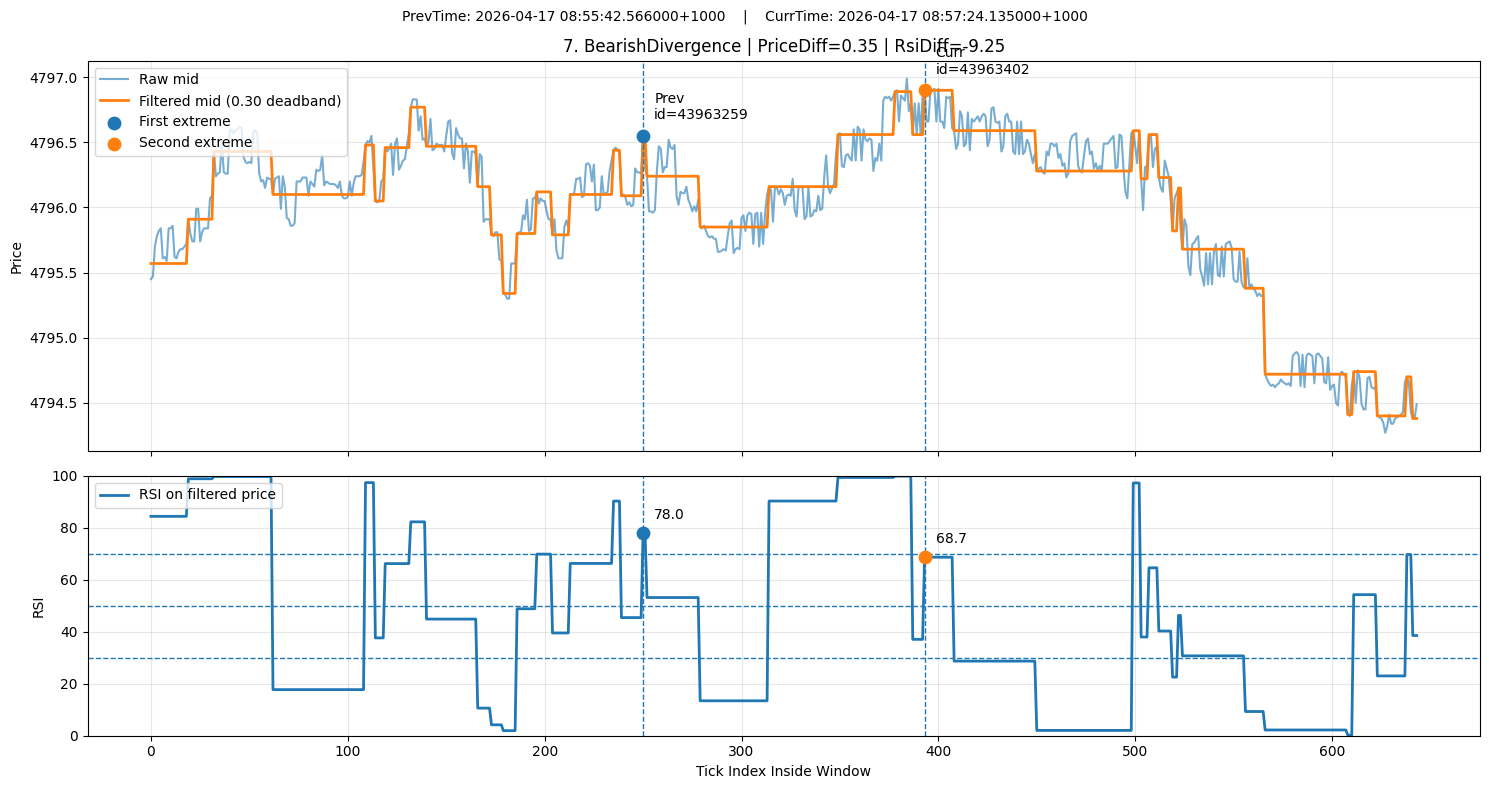

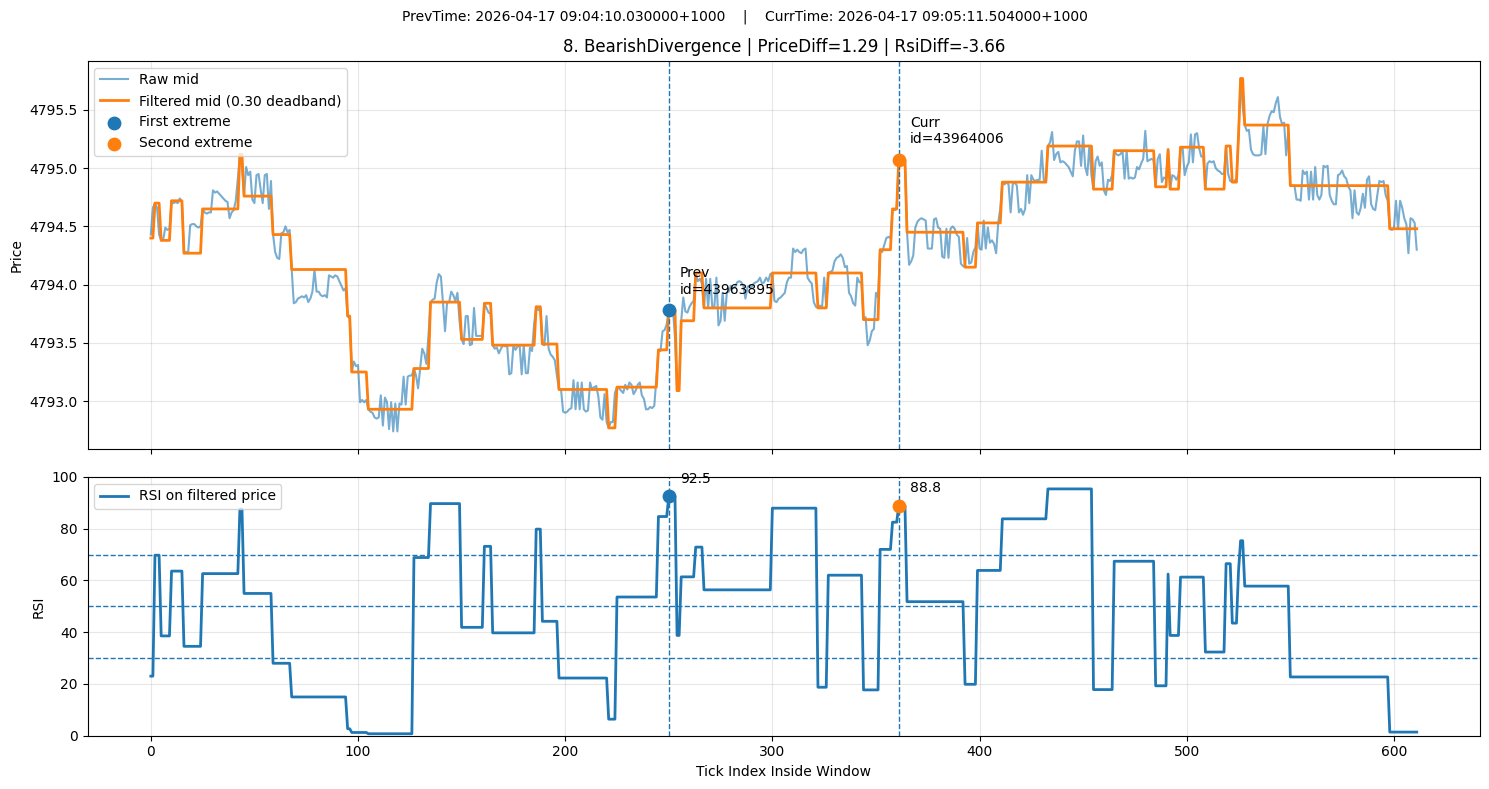

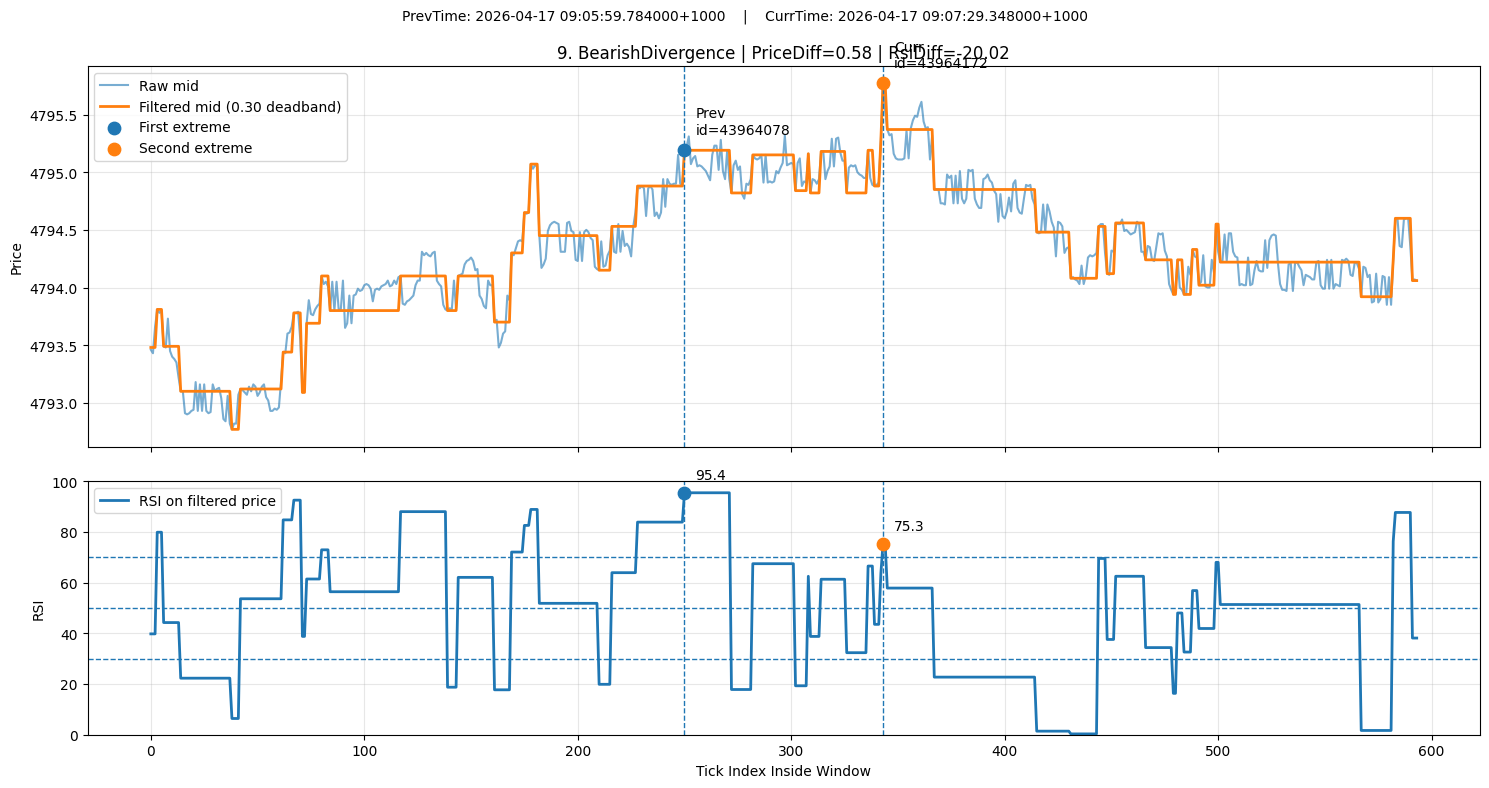

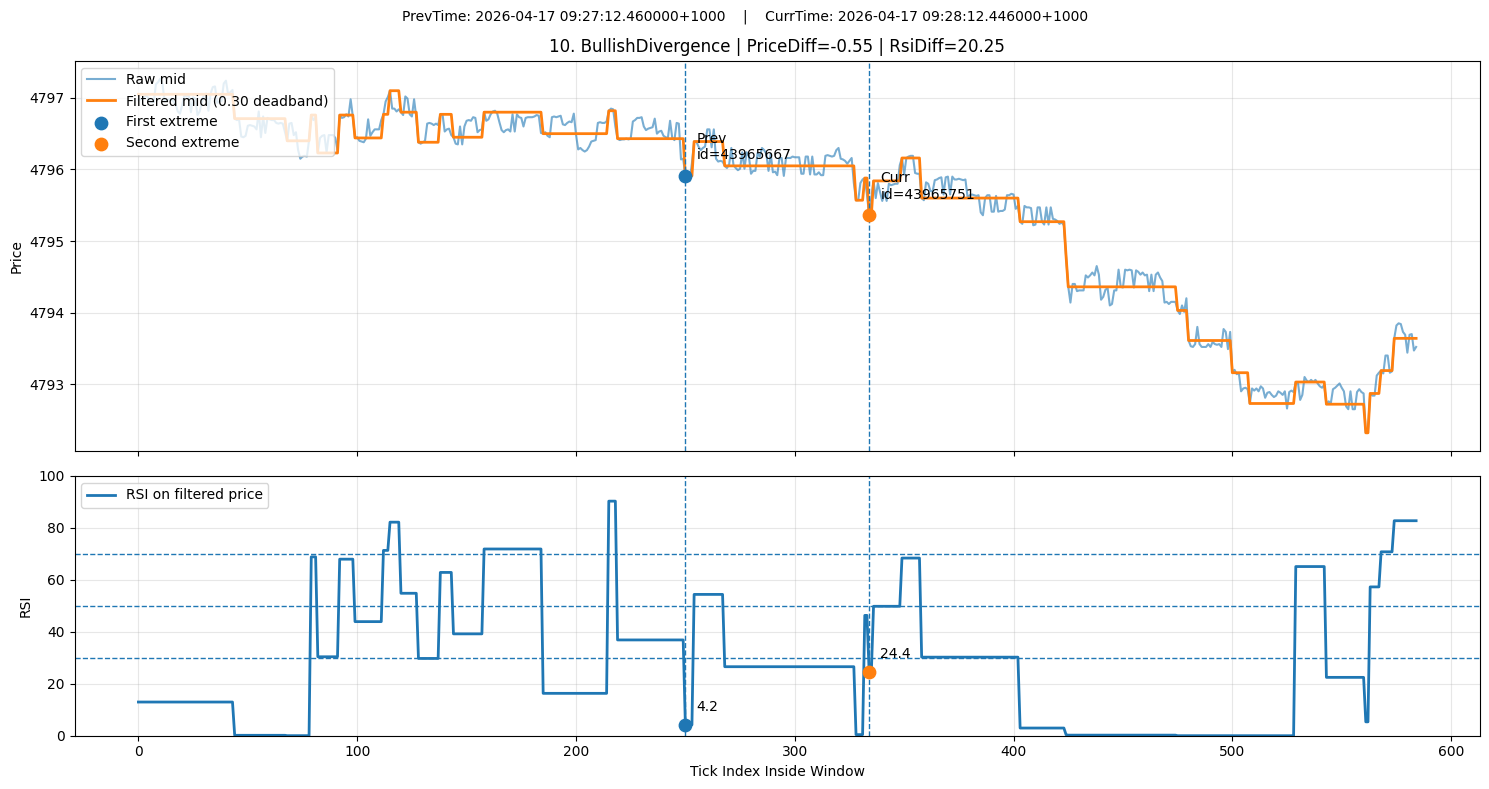

Done.


In [12]:
#9. draw the first 10 divergence pictures with exact marked ticks on both price and RSI

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

if "DfSignals" not in globals():
    raise ValueError("DfSignals does not exist. Run the divergence scan cell first.")

if "DfRsi" not in globals():
    raise ValueError("DfRsi does not exist. Run the RSI cell first.")

if DfSignals.empty:
    print("No divergence signals found.")
else:
    OutputFolder = Path("divergence_pictures")
    OutputFolder.mkdir(exist_ok=True)

    BeforeTicks = 250
    AfterTicks = 250
    MaxSignalsToDraw = 10

    # Map tick id -> row position in the full day dataframe
    DfPlot = DfRsi.reset_index(drop=True).copy()
    IdToPos = pd.Series(DfPlot.index.to_numpy(), index=DfPlot["id"]).to_dict()

    SignalsToDraw = (
        DfSignals.sort_values("CurrTime")
        .head(MaxSignalsToDraw)
        .reset_index(drop=True)
        .copy()
    )

    print(f"Drawing {len(SignalsToDraw)} signal pictures...")
    print(f"Saving into folder: {OutputFolder}")

    for SignalIndex, SignalRow in SignalsToDraw.iterrows():
        PrevId = int(SignalRow["PrevId"])
        CurrId = int(SignalRow["CurrId"])
        SignalType = SignalRow["SignalType"]

        if PrevId not in IdToPos or CurrId not in IdToPos:
            print(f"Skipping signal {SignalIndex + 1}: id not found in dataframe.")
            continue

        PrevPos = int(IdToPos[PrevId])
        CurrPos = int(IdToPos[CurrId])

        StartPos = max(0, min(PrevPos, CurrPos) - BeforeTicks)
        EndPos = min(len(DfPlot) - 1, max(PrevPos, CurrPos) + AfterTicks)

        WindowDf = DfPlot.iloc[StartPos:EndPos + 1].copy().reset_index(drop=True)

        # Local x positions inside this chart window
        PrevLocal = PrevPos - StartPos
        CurrLocal = CurrPos - StartPos

        WindowDf["WindowIndex"] = range(len(WindowDf))

        PrevPriceRaw = DfPlot.loc[PrevPos, "mid"]
        CurrPriceRaw = DfPlot.loc[CurrPos, "mid"]

        PrevPriceFiltered = DfPlot.loc[PrevPos, "FilteredMid30"]
        CurrPriceFiltered = DfPlot.loc[CurrPos, "FilteredMid30"]

        PrevRsi = DfPlot.loc[PrevPos, "RsiF"]
        CurrRsi = DfPlot.loc[CurrPos, "RsiF"]

        PrevTime = DfPlot.loc[PrevPos, "timestampText"]
        CurrTime = DfPlot.loc[CurrPos, "timestampText"]

        Figure, (AxisPrice, AxisRsi) = plt.subplots(
            2, 1,
            figsize=(15, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 2]}
        )

        # ---------------------------
        # Top panel: price
        # ---------------------------
        AxisPrice.plot(
            WindowDf["WindowIndex"],
            WindowDf["mid"],
            label="Raw mid",
            alpha=0.6
        )

        AxisPrice.plot(
            WindowDf["WindowIndex"],
            WindowDf["FilteredMid30"],
            label="Filtered mid (0.30 deadband)",
            linewidth=2
        )

        # Mark the two important ticks
        AxisPrice.axvline(PrevLocal, linestyle="--", linewidth=1)
        AxisPrice.axvline(CurrLocal, linestyle="--", linewidth=1)

        AxisPrice.scatter(
            [PrevLocal],
            [PrevPriceFiltered],
            s=80,
            zorder=5,
            label="First extreme"
        )

        AxisPrice.scatter(
            [CurrLocal],
            [CurrPriceFiltered],
            s=80,
            zorder=5,
            label="Second extreme"
        )

        AxisPrice.annotate(
            f"Prev\nid={PrevId}",
            xy=(PrevLocal, PrevPriceFiltered),
            xytext=(8, 12),
            textcoords="offset points"
        )

        AxisPrice.annotate(
            f"Curr\nid={CurrId}",
            xy=(CurrLocal, CurrPriceFiltered),
            xytext=(8, 12),
            textcoords="offset points"
        )

        AxisPrice.set_ylabel("Price")
        AxisPrice.set_title(
            f"{SignalIndex + 1}. {SignalType} | "
            f"PriceDiff={SignalRow['PriceDiff']:.2f} | "
            f"RsiDiff={SignalRow['RsiDiff']:.2f}"
        )
        AxisPrice.grid(True, alpha=0.3)
        AxisPrice.legend(loc="upper left")

        # ---------------------------
        # Bottom panel: RSI
        # ---------------------------
        AxisRsi.plot(
            WindowDf["WindowIndex"],
            WindowDf["RsiF"],
            label="RSI on filtered price",
            linewidth=2
        )

        AxisRsi.axhline(70, linestyle="--", linewidth=1)
        AxisRsi.axhline(50, linestyle="--", linewidth=1)
        AxisRsi.axhline(30, linestyle="--", linewidth=1)

        AxisRsi.axvline(PrevLocal, linestyle="--", linewidth=1)
        AxisRsi.axvline(CurrLocal, linestyle="--", linewidth=1)

        AxisRsi.scatter(
            [PrevLocal],
            [PrevRsi],
            s=80,
            zorder=5
        )

        AxisRsi.scatter(
            [CurrLocal],
            [CurrRsi],
            s=80,
            zorder=5
        )

        AxisRsi.annotate(
            f"{PrevRsi:.1f}",
            xy=(PrevLocal, PrevRsi),
            xytext=(8, 10),
            textcoords="offset points"
        )

        AxisRsi.annotate(
            f"{CurrRsi:.1f}",
            xy=(CurrLocal, CurrRsi),
            xytext=(8, 10),
            textcoords="offset points"
        )

        AxisRsi.set_xlabel("Tick Index Inside Window")
        AxisRsi.set_ylabel("RSI")
        AxisRsi.set_ylim(0, 100)
        AxisRsi.grid(True, alpha=0.3)
        AxisRsi.legend(loc="upper left")

        # Add time text
        Figure.suptitle(
            f"PrevTime: {PrevTime}    |    CurrTime: {CurrTime}",
            y=0.98,
            fontsize=10
        )

        plt.tight_layout()

        FileName = (
            f"{SignalIndex + 1:02d}_"
            f"{SignalType}_"
            f"Prev{PrevId}_Curr{CurrId}.png"
        )
        FilePath = OutputFolder / FileName
        Figure.savefig(FilePath, dpi=150, bbox_inches="tight")

        plt.show()
        plt.close(Figure)

    print("Done.")

C:\Users\Mr.Babak\AppData\Local\Temp\ipykernel_1956\4113145402.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\Mr.Babak\AppData\Local\Temp\ipykernel_1956\4113145402.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")


Total Tick Rows:        198,040
Backbone Pivot Count:   5,777
Backbone Move Count:    5,775
Median Threshold:       0.6144
Mean Threshold:         0.6260


,RowIndex,id,timestampText,price,PivotType
0,0,43958393,2026-04-17 08:01:00.952000+1000,4794.99,Start
1,28,43958421,2026-04-17 08:01:07.176000+1000,4797.22,High
2,45,43958438,2026-04-17 08:01:10.916000+1000,4792.14,Low
3,115,43958508,2026-04-17 08:01:42.648000+1000,4794.48,High
4,196,43958590,2026-04-17 08:02:12.198000+1000,4791.90,Low
5,223,43958617,2026-04-17 08:02:25.460000+1000,4792.81,High
6,227,43958621,2026-04-17 08:02:28.083000+1000,4791.78,Low
7,256,43958650,2026-04-17 08:02:38.723000+1000,4794.33,High
8,263,43958657,2026-04-17 08:02:40.632000+1000,4793.49,Low
9,268,43958662,2026-04-17 08:02:41.963000+1000,4794.44,High


,StartRowIndex,EndRowIndex,StartId,EndId,StartTime,EndTime,StartPrice,EndPrice,Direction,PriceDelta,TickCount,ThresholdAtConfirm
0,0,28,43958393,43958421,2026-04-17 08:01:00.952000+1000,2026-04-17 08:01:07.176000+1000,4794.99,4797.22,Up,2.23,29,0.548943
1,28,45,43958421,43958438,2026-04-17 08:01:07.176000+1000,2026-04-17 08:01:10.916000+1000,4797.22,4792.14,Down,-5.08,18,0.759499
2,45,115,43958438,43958508,2026-04-17 08:01:10.916000+1000,2026-04-17 08:01:42.648000+1000,4792.14,4794.48,Up,2.34,71,0.743348
3,115,196,43958508,43958590,2026-04-17 08:01:42.648000+1000,2026-04-17 08:02:12.198000+1000,4794.48,4791.90,Down,-2.58,82,0.723083
4,196,223,43958590,43958617,2026-04-17 08:02:12.198000+1000,2026-04-17 08:02:25.460000+1000,4791.90,4792.81,Up,0.91,28,0.722750
5,223,227,43958617,43958621,2026-04-17 08:02:25.460000+1000,2026-04-17 08:02:28.083000+1000,4792.81,4791.78,Down,-1.03,5,0.722344
6,227,256,43958621,43958650,2026-04-17 08:02:28.083000+1000,2026-04-17 08:02:38.723000+1000,4791.78,4794.33,Up,2.55,30,0.723480
7,256,263,43958650,43958657,2026-04-17 08:02:38.723000+1000,2026-04-17 08:02:40.632000+1000,4794.33,4793.49,Down,-0.84,8,0.724262
8,263,268,43958657,43958662,2026-04-17 08:02:40.632000+1000,2026-04-17 08:02:41.963000+1000,4793.49,4794.44,Up,0.95,6,0.730729
9,268,272,43958662,43958666,2026-04-17 08:02:41.963000+1000,2026-04-17 08:02:43.548000+1000,4794.44,4793.68,Down,-0.76,5,0.737887


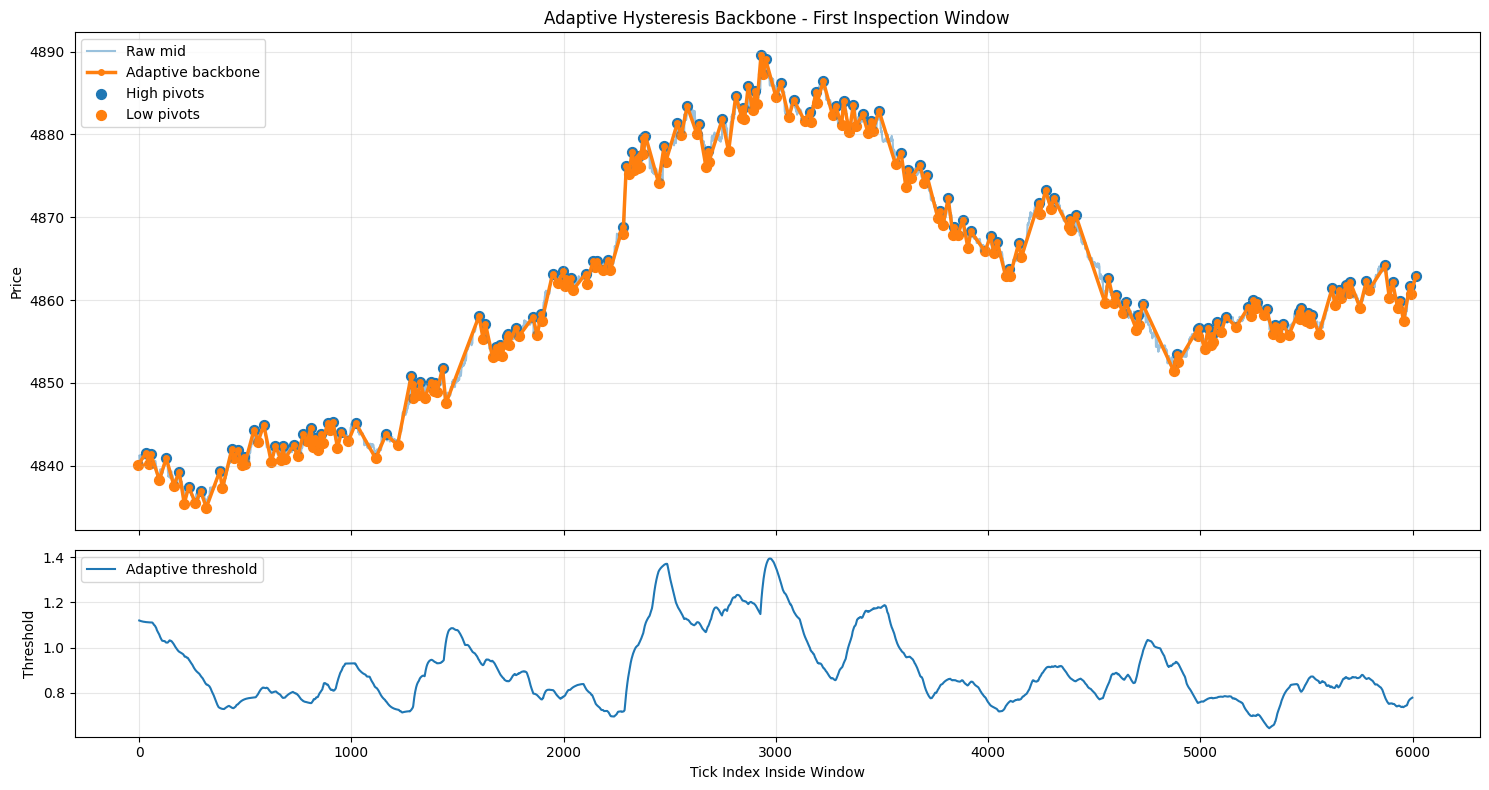

In [13]:
#8. build an adaptive hysteresis backbone from price, store pivots and moves, and draw a first inspection window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Source dataframe
# ------------------------------------------------------------
DfBase = (
    DfAc.dropna(subset=["timestamp", "mid"])
        .sort_values(["timestamp", "id"])
        .reset_index(drop=True)
        .copy()
)

# ------------------------------------------------------------
# Adaptive threshold components
# ------------------------------------------------------------
SpreadSpan = 100
NoiseWindow = 200
ThresholdSmoothSpan = 50

SpreadWeight = 0.50
DeltaQ80Weight = 3.00
DeltaStdWeight = 3.00
ThresholdFloor = 0.25

DfBase["Delta"] = DfBase["mid"].diff().fillna(0.0)
DfBase["AbsDelta"] = DfBase["Delta"].abs()

DfBase["SpreadEma"] = (
    DfBase["spread"]
    .fillna(method="ffill")
    .fillna(method="bfill")
    .ewm(span=SpreadSpan, adjust=False)
    .mean()
)

DfBase["AbsDeltaQ80"] = (
    DfBase["AbsDelta"]
    .rolling(window=NoiseWindow, min_periods=20)
    .quantile(0.80)
    .fillna(0.0)
)

DfBase["DeltaStdEwm"] = (
    DfBase["Delta"]
    .ewm(span=NoiseWindow, adjust=False)
    .std()
    .fillna(0.0)
)

ThresholdRaw = np.maximum.reduce([
    (DfBase["SpreadEma"] * SpreadWeight).to_numpy(),
    (DfBase["AbsDeltaQ80"] * DeltaQ80Weight).to_numpy(),
    (DfBase["DeltaStdEwm"] * DeltaStdWeight).to_numpy(),
    np.full(len(DfBase), ThresholdFloor, dtype=float),
])

DfBase["AdaptiveThresholdRaw"] = ThresholdRaw
DfBase["AdaptiveThreshold"] = (
    pd.Series(ThresholdRaw)
    .ewm(span=ThresholdSmoothSpan, adjust=False)
    .mean()
    .to_numpy()
)

# ------------------------------------------------------------
# Adaptive hysteresis backbone state machine
# ------------------------------------------------------------
IdValues = DfBase["id"].to_numpy()
TimeValues = DfBase["timestampText"].to_numpy()
PriceValues = DfBase["mid"].to_numpy()
ThresholdValues = DfBase["AdaptiveThreshold"].to_numpy()

PivotRows = []
MoveRows = []

ConfirmedPivotIndex = 0
ConfirmedPivotId = int(IdValues[0])
ConfirmedPivotTime = TimeValues[0]
ConfirmedPivotPrice = float(PriceValues[0])

PivotRows.append({
    "RowIndex": ConfirmedPivotIndex,
    "id": ConfirmedPivotId,
    "timestampText": ConfirmedPivotTime,
    "price": ConfirmedPivotPrice,
    "PivotType": "Start",
})

Direction = None
CandidateExtremeIndex = ConfirmedPivotIndex
CandidateExtremePrice = ConfirmedPivotPrice

for i in range(1, len(DfBase)):
    CurrentPrice = float(PriceValues[i])
    CurrentThreshold = float(ThresholdValues[i])

    if Direction is None:
        if CurrentPrice >= ConfirmedPivotPrice + CurrentThreshold:
            Direction = "Up"
            CandidateExtremeIndex = i
            CandidateExtremePrice = CurrentPrice
        elif CurrentPrice <= ConfirmedPivotPrice - CurrentThreshold:
            Direction = "Down"
            CandidateExtremeIndex = i
            CandidateExtremePrice = CurrentPrice
        continue

    if Direction == "Up":
        if CurrentPrice >= CandidateExtremePrice:
            CandidateExtremePrice = CurrentPrice
            CandidateExtremeIndex = i
        elif CandidateExtremePrice - CurrentPrice >= CurrentThreshold:
            NewPivotIndex = CandidateExtremeIndex
            NewPivotPrice = float(PriceValues[NewPivotIndex])
            NewPivotId = int(IdValues[NewPivotIndex])
            NewPivotTime = TimeValues[NewPivotIndex]

            PivotRows.append({
                "RowIndex": NewPivotIndex,
                "id": NewPivotId,
                "timestampText": NewPivotTime,
                "price": NewPivotPrice,
                "PivotType": "High",
            })

            MoveRows.append({
                "StartRowIndex": ConfirmedPivotIndex,
                "EndRowIndex": NewPivotIndex,
                "StartId": ConfirmedPivotId,
                "EndId": NewPivotId,
                "StartTime": ConfirmedPivotTime,
                "EndTime": NewPivotTime,
                "StartPrice": ConfirmedPivotPrice,
                "EndPrice": NewPivotPrice,
                "Direction": "Up",
                "PriceDelta": NewPivotPrice - ConfirmedPivotPrice,
                "TickCount": NewPivotIndex - ConfirmedPivotIndex + 1,
                "ThresholdAtConfirm": CurrentThreshold,
            })

            ConfirmedPivotIndex = NewPivotIndex
            ConfirmedPivotId = NewPivotId
            ConfirmedPivotTime = NewPivotTime
            ConfirmedPivotPrice = NewPivotPrice

            Direction = "Down"
            CandidateExtremeIndex = i
            CandidateExtremePrice = CurrentPrice

    elif Direction == "Down":
        if CurrentPrice <= CandidateExtremePrice:
            CandidateExtremePrice = CurrentPrice
            CandidateExtremeIndex = i
        elif CurrentPrice - CandidateExtremePrice >= CurrentThreshold:
            NewPivotIndex = CandidateExtremeIndex
            NewPivotPrice = float(PriceValues[NewPivotIndex])
            NewPivotId = int(IdValues[NewPivotIndex])
            NewPivotTime = TimeValues[NewPivotIndex]

            PivotRows.append({
                "RowIndex": NewPivotIndex,
                "id": NewPivotId,
                "timestampText": NewPivotTime,
                "price": NewPivotPrice,
                "PivotType": "Low",
            })

            MoveRows.append({
                "StartRowIndex": ConfirmedPivotIndex,
                "EndRowIndex": NewPivotIndex,
                "StartId": ConfirmedPivotId,
                "EndId": NewPivotId,
                "StartTime": ConfirmedPivotTime,
                "EndTime": NewPivotTime,
                "StartPrice": ConfirmedPivotPrice,
                "EndPrice": NewPivotPrice,
                "Direction": "Down",
                "PriceDelta": NewPivotPrice - ConfirmedPivotPrice,
                "TickCount": NewPivotIndex - ConfirmedPivotIndex + 1,
                "ThresholdAtConfirm": CurrentThreshold,
            })

            ConfirmedPivotIndex = NewPivotIndex
            ConfirmedPivotId = NewPivotId
            ConfirmedPivotTime = NewPivotTime
            ConfirmedPivotPrice = NewPivotPrice

            Direction = "Up"
            CandidateExtremeIndex = i
            CandidateExtremePrice = CurrentPrice

# Add the latest open extreme so the line reaches the most recent structure point
if CandidateExtremeIndex != PivotRows[-1]["RowIndex"]:
    PivotRows.append({
        "RowIndex": int(CandidateExtremeIndex),
        "id": int(IdValues[CandidateExtremeIndex]),
        "timestampText": TimeValues[CandidateExtremeIndex],
        "price": float(PriceValues[CandidateExtremeIndex]),
        "PivotType": "Live",
    })

DfBackbonePivots = pd.DataFrame(PivotRows).sort_values("RowIndex").reset_index(drop=True)
DfBackboneMoves = pd.DataFrame(MoveRows)

print(f"Total Tick Rows:        {len(DfBase):,}")
print(f"Backbone Pivot Count:   {len(DfBackbonePivots):,}")
print(f"Backbone Move Count:    {len(DfBackboneMoves):,}")
print(f"Median Threshold:       {DfBase['AdaptiveThreshold'].median():.4f}")
print(f"Mean Threshold:         {DfBase['AdaptiveThreshold'].mean():.4f}")

display(DfBackbonePivots.head(10))
display(DfBackboneMoves.head(10))

# ------------------------------------------------------------
# Choose one inspection window automatically
# ------------------------------------------------------------
ChartWindowSize = 6000

if len(DfBackbonePivots) >= 8:
    CenterPivotRow = int(DfBackbonePivots.iloc[len(DfBackbonePivots) // 2]["RowIndex"])
else:
    CenterPivotRow = len(DfBase) // 2

ChartStart = max(0, CenterPivotRow - (ChartWindowSize // 2))
ChartEnd = min(len(DfBase) - 1, ChartStart + ChartWindowSize - 1)
ChartStart = max(0, ChartEnd - ChartWindowSize + 1)

DfWindow = DfBase.iloc[ChartStart:ChartEnd + 1].copy().reset_index(drop=True)
DfWindow["WindowIndex"] = range(len(DfWindow))

PivotMask = (
    (DfBackbonePivots["RowIndex"] >= ChartStart) &
    (DfBackbonePivots["RowIndex"] <= ChartEnd)
)
DfWindowPivots = DfBackbonePivots.loc[PivotMask].copy()

# Include one pivot just before and just after the window so the backbone line connects properly
PrevPivots = DfBackbonePivots.loc[DfBackbonePivots["RowIndex"] < ChartStart]
NextPivots = DfBackbonePivots.loc[DfBackbonePivots["RowIndex"] > ChartEnd]

ExtraRows = []
if not PrevPivots.empty:
    ExtraRows.append(PrevPivots.tail(1))
if not NextPivots.empty:
    ExtraRows.append(NextPivots.head(1))

if ExtraRows:
    DfWindowPivots = pd.concat([DfWindowPivots] + ExtraRows, ignore_index=True)

DfWindowPivots = (
    DfWindowPivots.drop_duplicates(subset=["RowIndex"])
                  .sort_values("RowIndex")
                  .reset_index(drop=True)
)

DfWindowPivots["WindowIndex"] = DfWindowPivots["RowIndex"] - ChartStart

# ------------------------------------------------------------
# Draw first inspection chart
# ------------------------------------------------------------
Figure, (AxisPrice, AxisThreshold) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1.5]}
)

AxisPrice.plot(
    DfWindow["WindowIndex"],
    DfWindow["mid"],
    alpha=0.45,
    label="Raw mid"
)

AxisPrice.plot(
    DfWindowPivots["WindowIndex"],
    DfWindowPivots["price"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Adaptive backbone"
)

HighMask = DfWindowPivots["PivotType"] == "High"
LowMask = DfWindowPivots["PivotType"] == "Low"

AxisPrice.scatter(
    DfWindowPivots.loc[HighMask, "WindowIndex"],
    DfWindowPivots.loc[HighMask, "price"],
    s=50,
    label="High pivots"
)

AxisPrice.scatter(
    DfWindowPivots.loc[LowMask, "WindowIndex"],
    DfWindowPivots.loc[LowMask, "price"],
    s=50,
    label="Low pivots"
)

AxisPrice.set_title("Adaptive Hysteresis Backbone - First Inspection Window")
AxisPrice.set_ylabel("Price")
AxisPrice.grid(True, alpha=0.3)
AxisPrice.legend(loc="upper left")

AxisThreshold.plot(
    DfWindow["WindowIndex"],
    DfWindow["AdaptiveThreshold"],
    label="Adaptive threshold"
)
AxisThreshold.set_xlabel("Tick Index Inside Window")
AxisThreshold.set_ylabel("Threshold")
AxisThreshold.grid(True, alpha=0.3)
AxisThreshold.legend(loc="upper left")

plt.tight_layout()
plt.show()